<a href="https://colab.research.google.com/github/ManhattanCB01-nyc/CrashVehiclesDataPipeline/blob/main/finalcrashescode.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NYC Motor Vehicle Collisions — Data Pipeline
Downloads the NYC Open Data crashes dataset, enriches missing borough/zip via geospatial joins, runs EDA, and saves a clean CSV to Google Drive.

**Dataset:** Motor Vehicle Collisions – Crashes (h9gi-nx95)

**Fixes applied (2026-06-22):**
- Fix #1/#2: Incremental checkpoint uses date-only format; `>=` filter; stable ordering
- Fix #3: `collision_id` cast to `Int64` (nullable int) consistently across all datasets
- Fix #5: `run_nearest` now has missing-value mask — no longer overwrites resolved boroughs
- Fix #6: Section 8 guards against missing `geo_fixed` file
- Fix #7: Hour plot is fully dynamic — covers all 24 hours from live data
- Fix #8: Typo `'ILLNES'` corrected to `'ILLNESS'`

## 1. Setup

In [1]:
# Install geospatial dependencies (Colab only needs this once per runtime)
!pip install geopandas shapely -q

In [2]:
import os
import time
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import seaborn as sns

# ── Google Drive mount ──────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

# ── Paths ───────────────────────────────────────────────────────────────────
DRIVE_PATH  = "/content/drive/MyDrive/BigQueryDatasets/Collisions"
CSV_FILE    = os.path.join(DRIVE_PATH, "Collision_crashes.csv")
STATE_FILE  = os.path.join(DRIVE_PATH, "last_update.txt")
os.makedirs(DRIVE_PATH, exist_ok=True)

# ── NYC Socrata API ─────────────────────────────────────────────────────────
BASE_URL  = "https://data.cityofnewyork.us/resource/h9gi-nx95.csv"
PAGE_SIZE = 50_000

# ── NYC bounding box (used throughout for coord validation) ─────────────────
NYC_LAT = (40.49, 40.92)
NYC_LON = (-74.26, -73.70)

print("Setup complete.")

Mounted at /content/drive
Setup complete.


## 2. Download from Socrata API

In [3]:
import datetime

if os.path.exists(STATE_FILE):
    with open(STATE_FILE) as f:
        start_date_str = f.read().strip()
    try:
        start_datetime = datetime.datetime.fromisoformat(start_date_str)
        if start_datetime > datetime.datetime.now():
            print(f"Warning: Checkpoint {start_date_str} is in the future. Resetting.")
            start_date_for_download = "2018-01-01"
        else:
            # Socrata crash_date is DATE not DATETIME — use date-only format
            start_date_for_download = start_datetime.strftime("%Y-%m-%d")
            print(f"Incremental update from {start_date_for_download}")
    except ValueError:
        print(f"Warning: Invalid checkpoint '{start_date_str}'. Resetting.")
        start_date_for_download = "2018-01-01"
else:
    start_date_for_download = "2018-01-01"
    print(f"First run — downloading everything since {start_date_for_download}")


def download_data(start_date_param):
    chunks = []
    offset = 0
    while True:
        url = (
            f"{BASE_URL}"
            f"?$where=crash_date>='{start_date_param}'"
            f"&$limit={PAGE_SIZE}"
            f"&$offset={offset}"
            f"&$order=crash_date%20ASC" # Fixed: Replaced space with %20
        )
        print(f"  offset {offset:,} ...", end=" ")
        try:
            chunk = pd.read_csv(url)
        except Exception as e:
            print(f"FAILED — {e}")
            break
        if chunk.empty:
            print("done.")
            break
        print(f"{len(chunk):,} rows")
        chunks.append(chunk)
        offset += PAGE_SIZE
    return chunks


chunks = download_data(start_date_for_download)

if not chunks and start_date_for_download != "2018-01-01":
    print(f"No data with start_date='{start_date_for_download}'. Retrying from 2018-01-01.")
    start_date_for_download = "2018-01-01"
    chunks = download_data(start_date_for_download)

if not chunks:
    raise RuntimeError("No data downloaded — check the API URL / date filter.")

new_data = pd.concat(chunks, ignore_index=True)

# FIX #3: Cast collision_id to nullable Int64 early so all joins are consistent
new_data["collision_id"] = pd.to_numeric(new_data["collision_id"], errors="coerce").astype("Int64")

print(f"\nDownloaded {len(new_data):,} rows total.")

Incremental update from 2026-06-11
  offset 0 ... 12 rows
  offset 50,000 ... done.

Downloaded 12 rows total.


## 3. Merge with existing data & deduplicate

In [4]:
# Canonical column order comes from the freshly downloaded data
EXPECTED_COLS = new_data.columns.tolist()

def normalise_columns(df: pd.DataFrame, expected: list) -> pd.DataFrame:
    """Lowercase + underscore column names, drop extras, add missing."""
    df = df.copy()
    df.columns = df.columns.str.lower().str.replace(" ", "_", regex=False)
    df = df.loc[:, ~df.columns.duplicated()]
    df = df.drop(columns=[c for c in df.columns if c not in expected], errors="ignore")
    for col in expected:
        if col not in df.columns:
            df[col] = pd.NA
    return df[expected]


if os.path.exists(CSV_FILE):
    existing = normalise_columns(pd.read_csv(CSV_FILE, low_memory=False), EXPECTED_COLS)
    # FIX #3: consistent collision_id type on load
    existing["collision_id"] = pd.to_numeric(existing["collision_id"], errors="coerce").astype("Int64")
    print(f"Loaded {len(existing):,} existing rows from Drive.")
else:
    existing = pd.DataFrame(columns=EXPECTED_COLS)
    print("No existing file found — starting fresh.")

combined = pd.concat([existing, new_data], ignore_index=True)
before = len(combined)
combined = combined.drop_duplicates(subset=["collision_id"])
print(f"Removed {before - len(combined):,} duplicate rows — {len(combined):,} remain.")

Loaded 1,079,853 existing rows from Drive.
Removed 12 duplicate rows — 1,079,853 remain.


## 4. Exploratory Data Analysis

In [5]:
print(f"Shape: {combined.shape}")
combined.info()

Shape: (1079853, 29)
<class 'pandas.core.frame.DataFrame'>
Index: 1079853 entries, 0 to 1079852
Data columns (total 29 columns):
 #   Column                         Non-Null Count    Dtype  
---  ------                         --------------    -----  
 0   crash_date                     1079853 non-null  object 
 1   crash_time                     1079853 non-null  object 
 2   borough                        1079853 non-null  object 
 3   zip_code                       1079853 non-null  float64
 4   latitude                       1064429 non-null  float64
 5   longitude                      1064429 non-null  float64
 6   location                       1064429 non-null  object 
 7   on_street_name                 795002 non-null   object 
 8   off_street_name                536445 non-null   object 
 9   cross_street_name              284106 non-null   object 
 10  number_of_persons_injured      1079847 non-null  float64
 11  number_of_persons_killed       1070958 non-null  float64
 12

In [6]:
print("--- Descriptive Statistics (numeric columns) ---")
display(combined.describe())

--- Descriptive Statistics (numeric columns) ---


,zip_code,latitude,longitude,number_of_persons_injured,number_of_persons_killed,number_of_pedestrians_injured,number_of_pedestrians_killed,number_of_cyclist_injured,number_of_cyclist_killed,number_of_motorist_injured,number_of_motorist_killed,collision_id
count,1.079853e+06,1.064429e+06,1.064429e+06,1.079847e+06,1.070958e+06,1.079853e+06,1.079853e+06,1.079853e+06,1.079853e+06,1.079853e+06,1.079853e+06,1079853.0
mean,1.086619e+04,4.072485e+01,-7.391668e+01,4.167952e-01,2.031826e-03,7.088743e-02,9.399428e-04,3.972578e-02,1.824322e-04,2.962588e-01,8.464115e-04,4365024.208543
std,6.232491e+02,8.071474e-02,8.579957e-02,7.712769e-01,4.717683e-02,2.698568e-01,3.121298e-02,1.986475e-01,1.350552e-02,7.374584e-01,3.155497e-02,312796.295987
min,0.000000e+00,4.049895e+01,-7.425496e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3511951.0
25%,1.045300e+04,4.066725e+01,-7.396819e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4095642.0
50%,1.120800e+04,4.071878e+01,-7.392172e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4365738.0
75%,1.135400e+04,4.077759e+01,-7.386377e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4635753.0
max,1.234500e+04,4.091288e+01,-7.370048e+01,4.000000e+01,5.000000e+00,1.900000e+01,4.000000e+00,3.000000e+00,1.000000e+00,4.000000e+01,5.000000e+00,4905771.0


In [7]:
missing = combined.isnull().sum()
missing_pct = missing / len(combined) * 100
missing_df = pd.DataFrame({"count": missing, "pct": missing_pct.round(2)})
display(missing_df[missing_df["count"] > 0].sort_values("count", ascending=False))

,count,pct
vehicle_type_code_5,1073796,99.44
contributing_factor_vehicle_5,1073562,99.42
vehicle_type_code_4,1059226,98.09
contributing_factor_vehicle_4,1058164,97.99
vehicle_type_code_3,997663,92.39
contributing_factor_vehicle_3,992262,91.89
cross_street_name,795747,73.69
off_street_name,543408,50.32
vehicle_type_code2,303526,28.11
on_street_name,284851,26.38


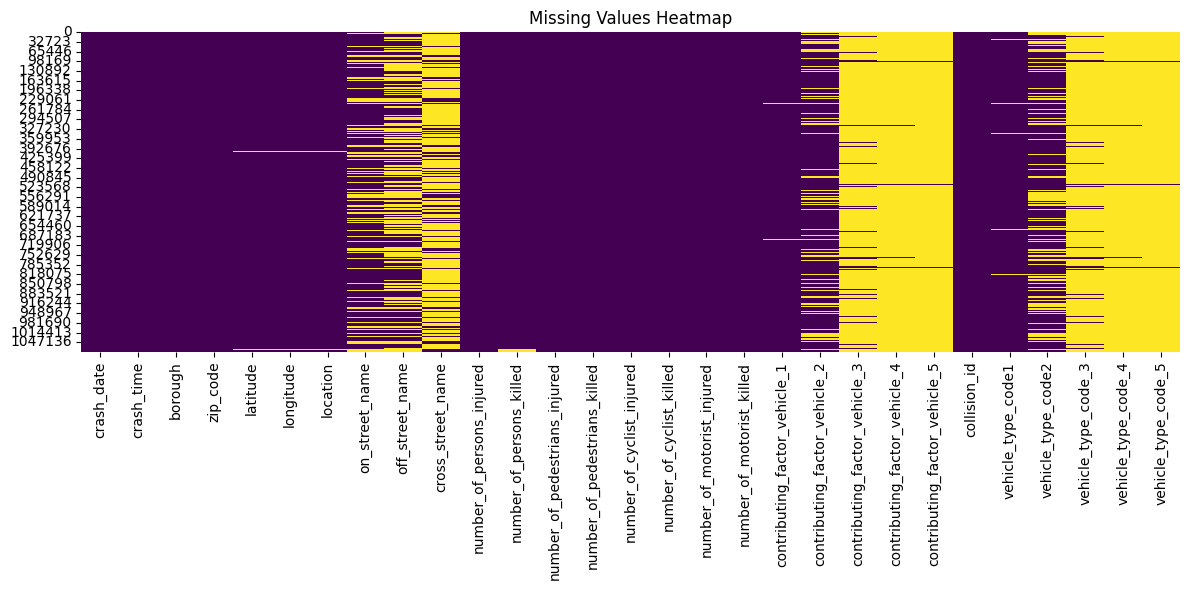

In [8]:
plt.figure(figsize=(12, 6))
sns.heatmap(combined.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.tight_layout()
plt.show()

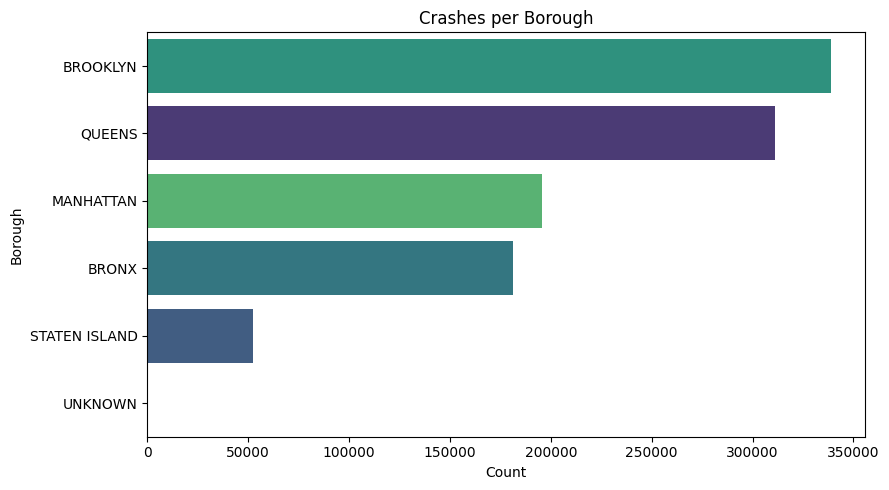

In [9]:
plt.figure(figsize=(9, 5))
order = combined["borough"].value_counts().index
ax = sns.countplot(
    y=combined["borough"],
    order=order,
    hue=combined["borough"],
    palette="viridis",
    legend=False,
)
ax.set_title("Crashes per Borough")
ax.set_xlabel("Count")
ax.set_ylabel("Borough")
plt.tight_layout()
plt.show()

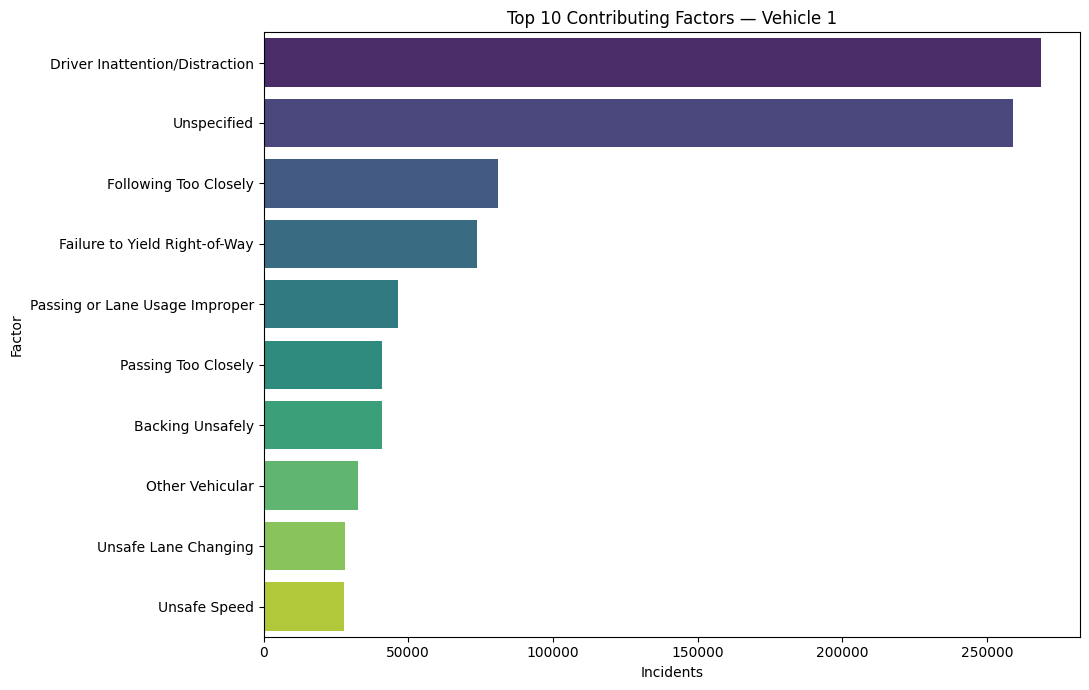

In [10]:
top10 = combined["contributing_factor_vehicle_1"].value_counts().head(10)
plt.figure(figsize=(11, 7))
ax = sns.barplot(
    x=top10.values,
    y=top10.index,
    hue=top10.index,
    palette="viridis",
    legend=False,
)
ax.set_title("Top 10 Contributing Factors — Vehicle 1")
ax.set_xlabel("Incidents")
ax.set_ylabel("Factor")
plt.tight_layout()
plt.show()

## 5. Geospatial Enrichment
Fills missing `borough` and `zip_code` via three methods in order:
1. **Polygon sjoin** — point-in-polygon against official NYC boundary files
2. **Street-average lookup** — fallback using average coords of known streets
3. **Nearest-neighbour join** — final fallback for points near polygon edges

In [11]:
import requests, io
import geopandas as gpd

def fetch_geojson(url: str, label: str) -> gpd.GeoDataFrame:
    """Download a GeoJSON URL into a GeoDataFrame without touching the filesystem."""
    resp = requests.get(url, timeout=30)
    resp.raise_for_status()
    if len(resp.content) < 500:
        raise RuntimeError(f"{label}: response too small ({len(resp.content)} bytes) — likely blocked.")
    gdf = gpd.read_file(io.BytesIO(resp.content))
    print(f"  {label}: {len(gdf)} polygons OK")
    return gdf

# Reliable GitHub raw sources
BOR_URL = "https://raw.githubusercontent.com/dwillis/nyc-maps/master/boroughs.geojson"
ZIP_URL = "https://raw.githubusercontent.com/fedhere/PUI2015_EC/master/mam1612_EC/nyc-zip-code-tabulation-areas-polygons.geojson"

borough_gdf = fetch_geojson(BOR_URL, "Boroughs").to_crs(epsg=4326)
zip_gdf     = fetch_geojson(ZIP_URL, "ZIP codes").to_crs(epsg=4326)

print("\nBorough columns:", borough_gdf.columns.tolist())
print("ZIP columns:    ", zip_gdf.columns.tolist())

# Normalise to standard column names
boro_col = next((c for c in borough_gdf.columns
                 if c.lower() in ["boroname", "borough", "name", "boro_name"]), None)
if boro_col and boro_col != "BoroName":
    borough_gdf = borough_gdf.rename(columns={boro_col: "BoroName"})

zip_col = next((c for c in zip_gdf.columns
                if c.lower() in ["postalcode", "zipcode", "zip", "modzcta",
                                  "zip_code", "zcta5ce10", "zipst"]), None)
if zip_col and zip_col != "MODZCTA":
    zip_gdf = zip_gdf.rename(columns={zip_col: "MODZCTA"})

borough_gdf = borough_gdf[["BoroName", "geometry"]]
zip_gdf     = zip_gdf[["MODZCTA", "geometry"]]

print("\nFinal borough columns:", borough_gdf.columns.tolist())
print("Final ZIP columns:    ", zip_gdf.columns.tolist())

  Boroughs: 5 polygons OK
  ZIP codes: 262 polygons OK

Borough columns: ['BoroCode', 'BoroName', 'Shape_Leng', 'Shape_Area', 'geometry']
ZIP columns:     ['OBJECTID', 'postalCode', 'PO_NAME', 'STATE', 'borough', 'ST_FIPS', 'CTY_FIPS', 'BLDGpostalCode', 'Shape_Leng', 'Shape_Area', '@id', 'geometry']

Final borough columns: ['BoroName', 'geometry']
Final ZIP columns:     ['MODZCTA', 'geometry']


In [12]:
def run_sjoin(df: pd.DataFrame,
              borough_gdf: gpd.GeoDataFrame,
              zip_gdf: gpd.GeoDataFrame,
              predicate: str = "within") -> None:
    """Point-in-polygon spatial join. Writes results into global `combined`."""
    if df.empty:
        return
    gdf = gpd.GeoDataFrame(
        df[[]],
        geometry=gpd.points_from_xy(df["longitude"], df["latitude"]),
        crs="EPSG:4326",
    )
    b_join = gpd.sjoin(gdf, borough_gdf, how="left", predicate=predicate)
    b_join = b_join.groupby(level=0).first()
    mask_b = combined.loc[b_join.index, "borough"].isna() | \
             (combined.loc[b_join.index, "borough"] == "UNKNOWN")
    combined.loc[b_join.index[mask_b], "borough"] = \
        b_join.loc[mask_b, "BoroName"].str.upper()

    z_join = gpd.sjoin(gdf, zip_gdf, how="left", predicate=predicate)
    z_join = z_join.groupby(level=0).first()
    mask_z = combined.loc[z_join.index, "zip_code"].isna() | \
             (combined.loc[z_join.index, "zip_code"] == 0)
    combined.loc[z_join.index[mask_z], "zip_code"] = \
        z_join.loc[mask_z, "MODZCTA"].astype(float)


# FIX #5: run_nearest now has the same missing-value mask as run_sjoin
def run_nearest(df: pd.DataFrame,
                borough_gdf: gpd.GeoDataFrame,
                zip_gdf: gpd.GeoDataFrame) -> None:
    """Nearest-neighbour fallback. Only fills rows that are still missing."""
    if df.empty:
        return
    gdf_proj = gpd.GeoDataFrame(
        df[[]],
        geometry=gpd.points_from_xy(df["longitude"], df["latitude"]),
        crs="EPSG:4326",
    ).to_crs(epsg=2263)  # NY State Plane (feet)

    b_proj = borough_gdf.to_crs(epsg=2263)
    z_proj = zip_gdf.to_crs(epsg=2263)

    b_near = gpd.sjoin_nearest(gdf_proj, b_proj[["BoroName", "geometry"]],
                               how="left").groupby(level=0).first()
    z_near = gpd.sjoin_nearest(gdf_proj, z_proj[["MODZCTA", "geometry"]],
                               how="left").groupby(level=0).first()

    # Only write where still missing — don't overwrite already-resolved rows
    mask_b = combined.loc[b_near.index, "borough"].isna() | \
             (combined.loc[b_near.index, "borough"] == "UNKNOWN")
    mask_z = combined.loc[z_near.index, "zip_code"].isna() | \
             (combined.loc[z_near.index, "zip_code"] == 0)

    combined.loc[b_near.index[mask_b], "borough"] = \
        b_near.loc[mask_b, "BoroName"].str.upper()
    combined.loc[z_near.index[mask_z], "zip_code"] = \
        z_near.loc[mask_z, "MODZCTA"].astype(float)

In [13]:
# Step 0: normalise types & null out garbage coordinates
combined["borough"]  = combined["borough"].replace(["None", "none", "NaN", "nan", "<NA>"], np.nan)
combined["zip_code"] = pd.to_numeric(combined["zip_code"], errors="coerce")

bad_coords = (
    combined["latitude"].notna() &
    (~combined["latitude"].between(*NYC_LAT) |
     ~combined["longitude"].between(*NYC_LON))
)
combined.loc[bad_coords, ["latitude", "longitude", "location"]] = np.nan
print(f"Nulled {bad_coords.sum():,} out-of-bounds coordinate rows.")

def missing_report():
    b = combined["borough"].isna().sum()
    z = combined["zip_code"].isna().sum()
    print(f"  borough missing: {b:,} | zip_code missing: {z:,}")

print("Before enrichment:")
missing_report()

Nulled 0 out-of-bounds coordinate rows.
Before enrichment:
  borough missing: 0 | zip_code missing: 0


In [14]:
# Step 1: Polygon sjoin for rows with valid NYC coords
needs_enrichment = (
    (combined["borough"].isna() | combined["zip_code"].isna()) &
    combined["latitude"].between(*NYC_LAT) &
    combined["longitude"].between(*NYC_LON)
)
print(f"Rows to enrich (polygon sjoin): {needs_enrichment.sum():,}")
run_sjoin(combined[needs_enrichment], borough_gdf, zip_gdf, predicate="within")
print("After polygon sjoin:")
missing_report()

Rows to enrich (polygon sjoin): 0
After polygon sjoin:
  borough missing: 0 | zip_code missing: 0


In [15]:
# Step 2: Street-average lookup for rows still missing coords
valid = combined[
    combined["latitude"].between(*NYC_LAT) &
    combined["longitude"].between(*NYC_LON)
].copy()
valid["street_key"] = valid["on_street_name"].astype(str).str.strip().str.upper()
street_map = valid.groupby("street_key")[["latitude", "longitude"]].mean()
print(f"Street lookup table: {len(street_map):,} unique streets.")

no_coords = combined["latitude"].isna() & combined["on_street_name"].notna()
combined["street_key"] = combined["on_street_name"].astype(str).str.strip().str.upper()
combined.loc[no_coords, "latitude"]  = combined.loc[no_coords, "street_key"].map(street_map["latitude"])
combined.loc[no_coords, "longitude"] = combined.loc[no_coords, "street_key"].map(street_map["longitude"])

filled = no_coords & combined["latitude"].notna()
combined.loc[filled, "location"] = combined.loc[filled].apply(
    lambda r: f"({r['latitude']:.6f}, {r['longitude']:.6f})", axis=1
)
combined.drop(columns=["street_key"], inplace=True, errors="ignore")
print(f"Street-average fill: {filled.sum():,} rows given approximate coords.")

needs_enrichment2 = (
    (combined["borough"].isna() | combined["zip_code"].isna()) &
    combined["latitude"].between(*NYC_LAT) &
    combined["longitude"].between(*NYC_LON)
)
run_sjoin(combined[needs_enrichment2], borough_gdf, zip_gdf, predicate="within")
print("After street-average + re-sjoin:")
missing_report()

Street lookup table: 10,075 unique streets.
Street-average fill: 0 rows given approximate coords.
After street-average + re-sjoin:
  borough missing: 0 | zip_code missing: 0


In [16]:
# Step 3: Nearest-neighbour fallback for remaining NYC-coord rows
still_missing = (
    (combined["borough"].isna() | combined["zip_code"].isna()) &
    combined["latitude"].between(*NYC_LAT) &
    combined["longitude"].between(*NYC_LON)
)
print(f"Rows for nearest-neighbour fallback: {still_missing.sum():,}")
run_nearest(combined[still_missing], borough_gdf, zip_gdf)
print("After nearest-neighbour fallback:")
missing_report()

Rows for nearest-neighbour fallback: 0
After nearest-neighbour fallback:
  borough missing: 0 | zip_code missing: 0


In [17]:
# Step 4: Fill truly unresolvable rows with sentinel values
combined["borough"]  = combined["borough"].fillna("UNKNOWN")
combined["zip_code"] = combined["zip_code"].fillna(0)

print("Final borough distribution:")
print(combined["borough"].value_counts())
print(f"\nRows with UNKNOWN borough: {(combined['borough'] == 'UNKNOWN').sum():,}")
print(f"Rows with zip_code == 0:   {(combined['zip_code'] == 0).sum():,}")

Final borough distribution:
borough
BROOKLYN         338954
QUEENS           311118
MANHATTAN        195573
BRONX            181497
STATEN ISLAND     52159
UNKNOWN             552
Name: count, dtype: int64

Rows with UNKNOWN borough: 552
Rows with zip_code == 0:   575


## 6. Final Cleanup & Save

In [18]:
before = len(combined)
combined = combined.dropna(subset=["collision_id"])
print(f"Dropped {before - len(combined):,} rows with null collision_id.")
print(f"Final dataset: {len(combined):,} rows × {len(combined.columns)} columns.")

Dropped 0 rows with null collision_id.
Final dataset: 1,079,853 rows × 29 columns.


In [19]:
combined.to_csv(CSV_FILE, index=False)
print(f"Saved to:\n  {CSV_FILE}")

# FIX #1/#2: Save checkpoint as date-only so next incremental run works
latest = pd.to_datetime(new_data["crash_date"]).max()
with open(STATE_FILE, "w") as f:
    f.write(latest.strftime("%Y-%m-%d"))
print(f"Checkpoint updated to: {latest.strftime('%Y-%m-%d')}")

Saved to:
  /content/drive/MyDrive/BigQueryDatasets/Collisions/Collision_crashes.csv
Checkpoint updated to: 2026-06-11


In [20]:
display(combined.head(5))

,crash_date,crash_time,borough,zip_code,latitude,longitude,location,on_street_name,off_street_name,cross_street_name,...,contributing_factor_vehicle_2,contributing_factor_vehicle_3,contributing_factor_vehicle_4,contributing_factor_vehicle_5,collision_id,vehicle_type_code1,vehicle_type_code2,vehicle_type_code_3,vehicle_type_code_4,vehicle_type_code_5
0,2021-09-11,2:39,QUEENS,11356.0,40.779213,-73.828764,"(40.779213, -73.828764)",WHITESTONE EXPRESSWAY,NaN,20 AVENUE,...,Unspecified,NaN,NaN,NaN,4455765,NaN,NaN,NaN,NaN,NaN
1,2018-01-02,12:20,STATEN ISLAND,10314.0,40.610936,-74.121540,"(40.610936, -74.121540)",STATEN ISLAND EXPRESSWAY,NaN,NaN,...,Unspecified,NaN,NaN,NaN,3821254,Sedan,Sedan,NaN,NaN,NaN
2,2018-01-02,13:47,BRONX,10453.0,40.855385,-73.918100,"(40.855385, -73.9181)",MAJOR DEEGAN EXPRESSWAY,NaN,NaN,...,NaN,NaN,NaN,NaN,3821360,Sedan,NaN,NaN,NaN,NaN
3,2018-01-02,15:45,QUEENS,11377.0,40.735025,-73.894781,"(40.735025, -73.894781)",69 STREET,BORDEN AVENUE,NaN,...,Unspecified,NaN,NaN,NaN,3821289,Pick-up Truck,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN
4,2018-01-02T00:00:00.000,18:10,QUEENS,11430.0,NaN,NaN,NaN,CLEARVIEW EXPRESSWAY service roa,NORTHERN BOULEVARD,NaN,...,Unspecified,NaN,NaN,NaN,3821374,Sedan,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN


## 7. Save rows with missing geospatial data

In [21]:
missing_geo_data = combined[(combined['borough'] == 'UNKNOWN') | (combined['zip_code'] == 0)]
MISSING_GEO_CSV_FILE = os.path.join(DRIVE_PATH, "Collision_crashes_missing_geo.csv")
missing_geo_data.to_csv(MISSING_GEO_CSV_FILE, index=False)
print(f"Saved {len(missing_geo_data):,} rows with missing geospatial data to:\n  {MISSING_GEO_CSV_FILE}")
display(missing_geo_data.head())

Saved 575 rows with missing geospatial data to:
  /content/drive/MyDrive/BigQueryDatasets/Collisions/Collision_crashes_missing_geo.csv


,crash_date,crash_time,borough,zip_code,latitude,longitude,location,on_street_name,off_street_name,cross_street_name,...,contributing_factor_vehicle_2,contributing_factor_vehicle_3,contributing_factor_vehicle_4,contributing_factor_vehicle_5,collision_id,vehicle_type_code1,vehicle_type_code2,vehicle_type_code_3,vehicle_type_code_4,vehicle_type_code_5
3062,2018-01-07T00:00:00.000,6:43,MANHATTAN,0.0,NaN,NaN,NaN,belt parkway west,west street,NaN,...,NaN,NaN,NaN,NaN,3825829,Sedan,NaN,NaN,NaN,NaN
36477,2018-03-05T00:00:00.000,19:15,MANHATTAN,0.0,NaN,NaN,NaN,SUNNYMEAD VILLAGE,NaN,NaN,...,NaN,NaN,NaN,NaN,3857682,NaN,NaN,NaN,NaN,NaN
162487,2018-09-17T00:00:00.000,10:20,MANHATTAN,0.0,NaN,NaN,NaN,BELT PARKWAY WEST,KNAPP ST,NaN,...,Unspecified,NaN,NaN,NaN,3982466,Sedan,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN
189391,2018-10-28T00:00:00.000,2:25,MANHATTAN,0.0,NaN,NaN,NaN,Midtown Tunnel Exit,East 38 Street,NaN,...,Unspecified,NaN,NaN,NaN,4010375,Taxi,Taxi,NaN,NaN,NaN
404423,2019-10-25T00:00:00.000,13:50,MANHATTAN,0.0,NaN,NaN,NaN,NaN,NaN,90 west,...,Driver Inattention/Distraction,NaN,NaN,NaN,4230933,Carry All,Sedan,NaN,NaN,NaN


## 8. Incorporate Fixed Geospatial Data

In [22]:
# FIX #6: Guard against missing file — pipeline won't crash on fresh runtimes
FIXED_GEO_CSV_FILE = "/content/drive/MyDrive/BigQueryDatasets/Collisions/Collision_crashes_geo_fixed.csv"

if not os.path.exists(FIXED_GEO_CSV_FILE):
    print("   geo_fixed file not found — skipping Section 8. Run geospatial fix export first.")
else:
    fixed_data = pd.read_csv(FIXED_GEO_CSV_FILE)
    print(f"Loaded {len(fixed_data):,} rows from fixed geospatial data file.")

    fixed_data = normalise_columns(fixed_data, EXPECTED_COLS)
    # FIX #3: consistent collision_id type
    fixed_data["collision_id"] = pd.to_numeric(fixed_data["collision_id"], errors="coerce").astype("Int64")

    combined_indexed = combined.set_index("collision_id")
    fixed_indexed    = fixed_data.set_index("collision_id")
    combined_indexed.update(fixed_indexed)

    combined = combined_indexed.reset_index()
    combined["collision_id"] = pd.to_numeric(combined["collision_id"], errors="coerce").astype("Int64")

    print(f"Updated {len(fixed_data):,} rows in the main dataset.")
    print(f"Rows with UNKNOWN borough after update: {(combined['borough'] == 'UNKNOWN').sum():,}")
    print(f"Rows with zip_code == 0 after update:   {(combined['zip_code'] == 0).sum():,}")

    combined.to_csv(CSV_FILE, index=False)
    print(f"Updated main dataset saved to:\n  {CSV_FILE}")
    display(combined.head())

Loaded 5,195 rows from fixed geospatial data file.
Updated 5,195 rows in the main dataset.
Rows with UNKNOWN borough after update: 552
Rows with zip_code == 0 after update:   575
Updated main dataset saved to:
  /content/drive/MyDrive/BigQueryDatasets/Collisions/Collision_crashes.csv


,collision_id,crash_date,crash_time,borough,zip_code,latitude,longitude,location,on_street_name,off_street_name,...,contributing_factor_vehicle_1,contributing_factor_vehicle_2,contributing_factor_vehicle_3,contributing_factor_vehicle_4,contributing_factor_vehicle_5,vehicle_type_code1,vehicle_type_code2,vehicle_type_code_3,vehicle_type_code_4,vehicle_type_code_5
0,4455765,2021-09-11,2:39,QUEENS,11356.0,40.779213,-73.828764,"(40.779213, -73.828764)",WHITESTONE EXPRESSWAY,NaN,...,Aggressive Driving/Road Rage,Unspecified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3821254,2018-01-02,12:20,STATEN ISLAND,10314.0,40.610936,-74.121540,"(40.610936, -74.121540)",STATEN ISLAND EXPRESSWAY,NaN,...,Reaction to Uninvolved Vehicle,Unspecified,NaN,NaN,NaN,Sedan,Sedan,NaN,NaN,NaN
2,3821360,2018-01-02,13:47,BRONX,10453.0,40.855385,-73.918100,"(40.855385, -73.9181)",MAJOR DEEGAN EXPRESSWAY,NaN,...,Unspecified,NaN,NaN,NaN,NaN,Sedan,NaN,NaN,NaN,NaN
3,3821289,2018-01-02,15:45,QUEENS,11377.0,40.735025,-73.894781,"(40.735025, -73.894781)",69 STREET,BORDEN AVENUE,...,Unspecified,Unspecified,NaN,NaN,NaN,Pick-up Truck,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN
4,3821374,2018-01-02T00:00:00.000,18:10,QUEENS,11430.0,NaN,NaN,NaN,CLEARVIEW EXPRESSWAY service roa,NORTHERN BOULEVARD,...,Driver Inattention/Distraction,Unspecified,NaN,NaN,NaN,Sedan,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN


### Exploratory Data Analysis of Fixed Geospatial Data

Shape of fixed_data: (5195, 29)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5195 entries, 0 to 5194
Data columns (total 29 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   crash_date                     5195 non-null   object 
 1   crash_time                     5195 non-null   object 
 2   borough                        5195 non-null   object 
 3   zip_code                       5175 non-null   float64
 4   latitude                       0 non-null      float64
 5   longitude                      0 non-null      float64
 6   location                       0 non-null      float64
 7   on_street_name                 2244 non-null   object 
 8   off_street_name                2041 non-null   object 
 9   cross_street_name              2627 non-null   object 
 10  number_of_persons_injured      5194 non-null   float64
 11  number_of_persons_killed       5163 non-null   float64
 12  number_of_pedest

,zip_code,latitude,longitude,location,number_of_persons_injured,number_of_persons_killed,number_of_pedestrians_injured,number_of_pedestrians_killed,number_of_cyclist_injured,number_of_cyclist_killed,number_of_motorist_injured,number_of_motorist_killed,collision_id
count,5175.000000,0.0,0.0,0.0,5194.000000,5163.000000,5195.000000,5195.000000,5195.000000,5195.000000,5195.000000,5195.000000,5195.0
mean,9779.958454,NaN,NaN,NaN,0.419137,0.004261,0.063715,0.001347,0.120885,0.000577,0.219442,0.002310,4332696.59538
std,3419.638767,NaN,NaN,NaN,0.703563,0.065144,0.255064,0.036686,0.342723,0.024026,0.617708,0.048011,311818.952228
min,0.000000,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3821235.0
25%,10314.000000,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4049203.5
50%,11204.000000,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4334245.0
75%,11375.000000,NaN,NaN,NaN,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4604361.5
max,11697.000000,NaN,NaN,NaN,8.000000,1.000000,4.000000,1.000000,2.000000,1.000000,8.000000,1.000000,4905349.0


,count,pct
latitude,5195,100.00
longitude,5195,100.00
location,5195,100.00
contributing_factor_vehicle_5,5172,99.56
vehicle_type_code_5,5171,99.54
vehicle_type_code_4,5135,98.85
contributing_factor_vehicle_4,5131,98.77
vehicle_type_code_3,4899,94.30
contributing_factor_vehicle_3,4881,93.96
off_street_name,3154,60.71


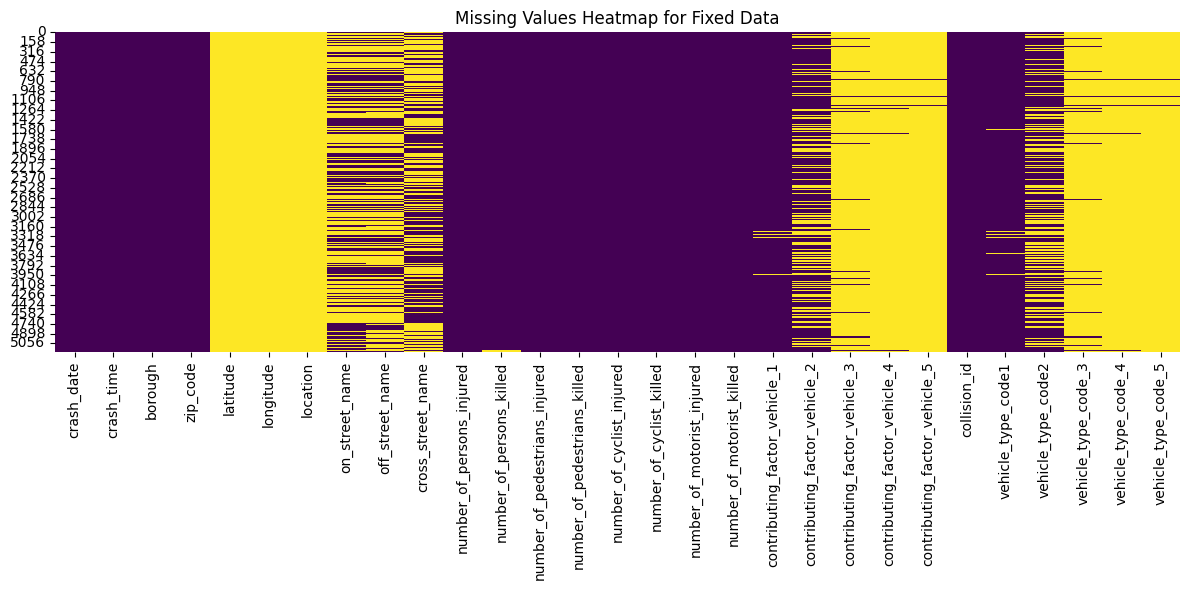

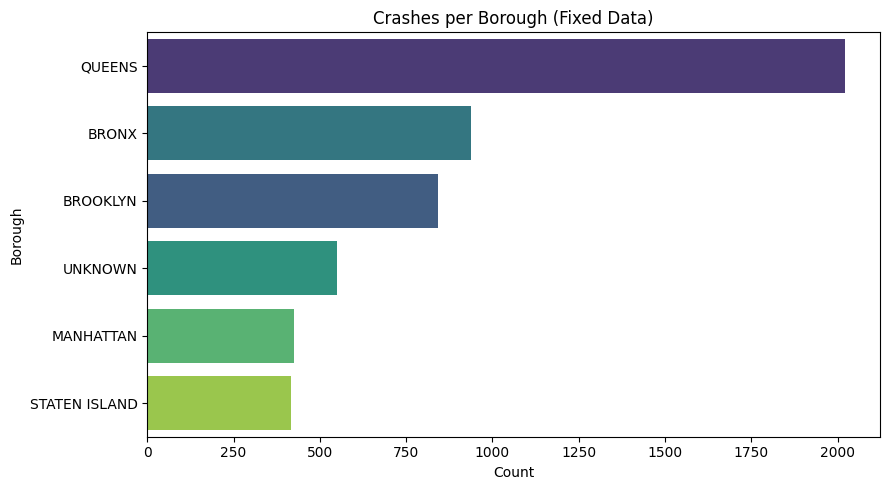

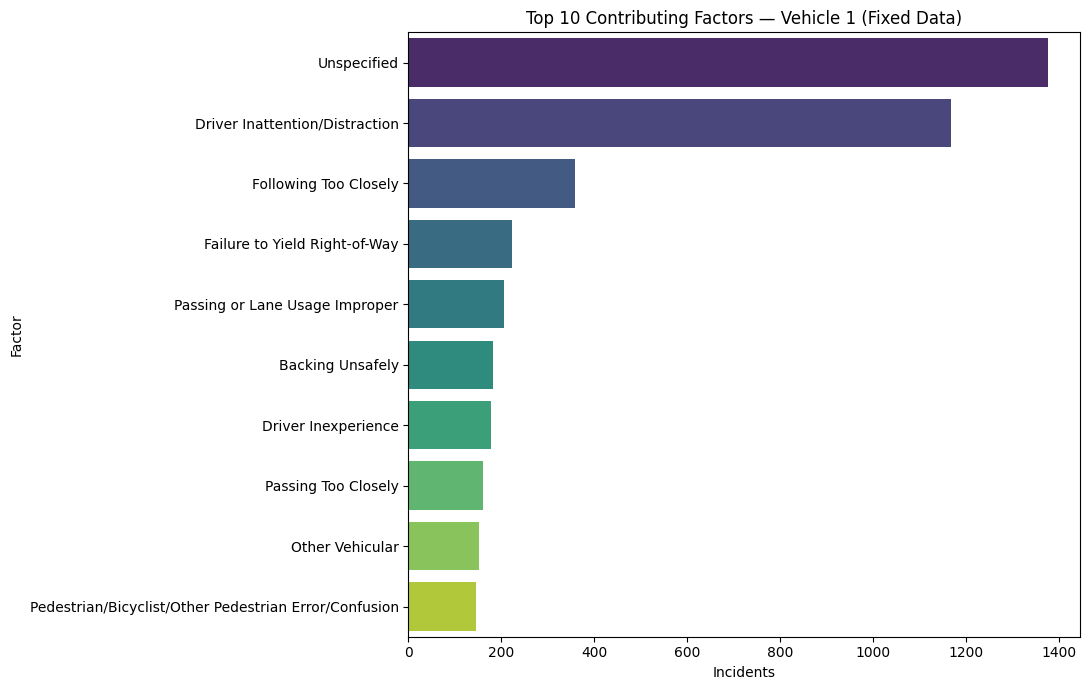

In [23]:
if 'fixed_data' in dir() and fixed_data is not None:
    print(f"Shape of fixed_data: {fixed_data.shape}")
    fixed_data.info()

    print("--- Descriptive Statistics (numeric columns) for fixed_data ---")
    display(fixed_data.describe())

    missing_fixed = fixed_data.isnull().sum()
    missing_pct_fixed = missing_fixed / len(fixed_data) * 100
    missing_df_fixed = pd.DataFrame({"count": missing_fixed, "pct": missing_pct_fixed.round(2)})
    display(missing_df_fixed[missing_df_fixed["count"] > 0].sort_values("count", ascending=False))

    plt.figure(figsize=(12, 6))
    sns.heatmap(fixed_data.isnull(), cbar=False, cmap="viridis")
    plt.title("Missing Values Heatmap for Fixed Data")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(9, 5))
    order_fixed = fixed_data["borough"].value_counts().index
    ax_fixed = sns.countplot(
        y=fixed_data["borough"], order=order_fixed,
        hue=fixed_data["borough"], palette="viridis", legend=False,
    )
    ax_fixed.set_title("Crashes per Borough (Fixed Data)")
    ax_fixed.set_xlabel("Count")
    ax_fixed.set_ylabel("Borough")
    plt.tight_layout()
    plt.show()

    top10_fixed = fixed_data["contributing_factor_vehicle_1"].value_counts().head(10)
    plt.figure(figsize=(11, 7))
    ax_fixed = sns.barplot(
        x=top10_fixed.values, y=top10_fixed.index,
        hue=top10_fixed.index, palette="viridis", legend=False,
    )
    ax_fixed.set_title("Top 10 Contributing Factors — Vehicle 1 (Fixed Data)")
    ax_fixed.set_xlabel("Incidents")
    ax_fixed.set_ylabel("Factor")
    plt.tight_layout()
    plt.show()
else:
    print("Section 8 was skipped — no fixed_data to analyse.")

## 9. Re-check Missing Geospatial Values

In [24]:
unknown_boroughs_current = (combined['borough'] == 'UNKNOWN').sum()
zero_zipcodes_current    = (combined['zip_code'] == 0).sum()
print(f"Current rows with UNKNOWN borough: {unknown_boroughs_current:,}")
print(f"Current rows with zip_code == 0:   {zero_zipcodes_current:,}")

Current rows with UNKNOWN borough: 552
Current rows with zip_code == 0:   575


In [25]:
missing_geo_current = combined[(combined['borough'] == 'UNKNOWN') & (combined['zip_code'] == 0)]
display(missing_geo_current.tail(20))

,collision_id,crash_date,crash_time,borough,zip_code,latitude,longitude,location,on_street_name,off_street_name,...,contributing_factor_vehicle_1,contributing_factor_vehicle_2,contributing_factor_vehicle_3,contributing_factor_vehicle_4,contributing_factor_vehicle_5,vehicle_type_code1,vehicle_type_code2,vehicle_type_code_3,vehicle_type_code_4,vehicle_type_code_5
1079833,4751892,2024-08-30T00:00:00.000,14:52,UNKNOWN,0.0,NaN,NaN,NaN,NaN,NaN,...,Driver Inattention/Distraction,Unspecified,NaN,NaN,NaN,Sedan,Sedan,NaN,NaN,NaN
1079834,4754089,2024-09-02T00:00:00.000,12:16,UNKNOWN,0.0,NaN,NaN,NaN,NaN,NaN,...,Unspecified,NaN,NaN,NaN,NaN,Bike,NaN,NaN,NaN,NaN
1079835,4752882,2024-09-03T00:00:00.000,21:20,UNKNOWN,0.0,NaN,NaN,NaN,NaN,NaN,...,Driver Inattention/Distraction,Driver Inattention/Distraction,NaN,NaN,NaN,Station Wagon/Sport Utility Vehicle,Bike,NaN,NaN,NaN
1079836,4754801,2024-09-09T00:00:00.000,11:23,UNKNOWN,0.0,NaN,NaN,NaN,NaN,NaN,...,Turning Improperly,Unspecified,NaN,NaN,NaN,Pick-up Truck,Box Truck,NaN,NaN,NaN
1079837,4757777,2024-09-09T00:00:00.000,9:30,UNKNOWN,0.0,NaN,NaN,NaN,NaN,NaN,...,Unspecified,NaN,NaN,NaN,NaN,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN,NaN
1079838,4754946,2024-09-11T00:00:00.000,6:00,UNKNOWN,0.0,NaN,NaN,NaN,NaN,NaN,...,Traffic Control Disregarded,Unspecified,NaN,NaN,NaN,Sedan,E-Bike,NaN,NaN,NaN
1079839,4757850,2024-09-19T00:00:00.000,14:30,UNKNOWN,0.0,NaN,NaN,NaN,NaN,NaN,...,Unspecified,NaN,NaN,NaN,NaN,Bus,NaN,NaN,NaN,NaN
1079840,4758081,2024-09-22T00:00:00.000,23:34,UNKNOWN,0.0,NaN,NaN,NaN,NaN,NaN,...,Driver Inattention/Distraction,Driver Inattention/Distraction,NaN,NaN,NaN,Sedan,Ambulance,NaN,NaN,NaN
1079841,4758870,2024-09-24T00:00:00.000,13:00,UNKNOWN,0.0,NaN,NaN,NaN,NaN,NaN,...,Unspecified,Unspecified,NaN,NaN,NaN,Sedan,Sedan,NaN,NaN,NaN
1079842,4758761,2024-09-25T00:00:00.000,18:00,UNKNOWN,0.0,NaN,NaN,NaN,NaN,NaN,...,Passing or Lane Usage Improper,Unspecified,NaN,NaN,NaN,Station Wagon/Sport Utility Vehicle,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN


In [26]:
before_drop = len(combined)
combined = combined[~((combined['borough'] == 'UNKNOWN') & (combined['zip_code'] == 0))]
print(f"Dropped {before_drop - len(combined):,} rows with UNKNOWN borough and 0 zip code.")
print(f"New shape of combined DataFrame: {combined.shape}")

Dropped 552 rows with UNKNOWN borough and 0 zip code.
New shape of combined DataFrame: (1079301, 29)


In [27]:
unknown_boroughs_after_drop = (combined['borough'] == 'UNKNOWN').sum()
zero_zipcodes_after_drop    = (combined['zip_code'] == 0).sum()
print(f"Current rows with UNKNOWN borough after drop: {unknown_boroughs_after_drop:,}")
print(f"Current rows with zip_code == 0 after drop:   {zero_zipcodes_after_drop:,}")

Current rows with UNKNOWN borough after drop: 0
Current rows with zip_code == 0 after drop:   23


In [28]:
manhattan_fixed_data = combined[combined['borough'] == 'MANHATTAN']
print(f"Shape of fixed data for Manhattan: {manhattan_fixed_data.shape}")
manhattan_fixed_data.info()
print("\nValue counts for 'borough' in Manhattan fixed data:")
display(manhattan_fixed_data['borough'].value_counts())
print("\nValue counts for 'zip_code' in Manhattan fixed data (top 20):")
display(manhattan_fixed_data['zip_code'].value_counts().head(20))

Shape of fixed data for Manhattan: (195573, 29)
<class 'pandas.core.frame.DataFrame'>
Index: 195573 entries, 10 to 1079297
Data columns (total 29 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   collision_id                   195573 non-null  Int64  
 1   crash_date                     195573 non-null  object 
 2   crash_time                     195573 non-null  object 
 3   borough                        195573 non-null  object 
 4   zip_code                       195573 non-null  float64
 5   latitude                       192847 non-null  float64
 6   longitude                      192847 non-null  float64
 7   location                       192847 non-null  object 
 8   on_street_name                 144434 non-null  object 
 9   off_street_name                90074 non-null   object 
 10  cross_street_name              51138 non-null   object 
 11  number_of_persons_injured      195573 non-null

,count
borough,
MANHATTAN,195573



Value counts for 'zip_code' in Manhattan fixed data (top 20):


,count
zip_code,
10002.0,11826
10035.0,9842
10029.0,9438
10019.0,7952
10016.0,7693
10027.0,7591
10036.0,7502
10013.0,7474
10001.0,7402


In [29]:
MANHATTAN_CSV_FILE = os.path.join(DRIVE_PATH, "Manhattan_fixed_data.csv")
manhattan_fixed_data.to_csv(MANHATTAN_CSV_FILE, index=False)
print(f"Manhattan data saved to:\n  {MANHATTAN_CSV_FILE}")

Manhattan data saved to:
  /content/drive/MyDrive/BigQueryDatasets/Collisions/Manhattan_fixed_data.csv


### EDA for Specific Manhattan Zip Codes

In [30]:
specific_manhattan_zipcodes = [10004, 10005, 10006, 10007, 10038, 10280, 10282, 10013, 10002, 10281]
manhattan_filtered_by_zip = manhattan_fixed_data[
    manhattan_fixed_data['zip_code'].isin(specific_manhattan_zipcodes)
].copy()
print(f"Shape of Manhattan data filtered by specific zip codes: {manhattan_filtered_by_zip.shape}")
manhattan_filtered_by_zip.info()

Shape of Manhattan data filtered by specific zip codes: (27074, 29)
<class 'pandas.core.frame.DataFrame'>
Index: 27074 entries, 67 to 1079297
Data columns (total 29 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   collision_id                   27074 non-null  Int64  
 1   crash_date                     27074 non-null  object 
 2   crash_time                     27074 non-null  object 
 3   borough                        27074 non-null  object 
 4   zip_code                       27074 non-null  float64
 5   latitude                       26576 non-null  float64
 6   longitude                      26576 non-null  float64
 7   location                       26576 non-null  object 
 8   on_street_name                 19280 non-null  object 
 9   off_street_name                13454 non-null  object 
 10  cross_street_name              7794 non-null   object 
 11  number_of_persons_injured      27074 non

In [31]:
print("--- Descriptive Statistics (numeric columns) for filtered Manhattan data ---")
display(manhattan_filtered_by_zip.describe())

missing_filtered = manhattan_filtered_by_zip.isnull().sum()
missing_pct_filtered = missing_filtered / len(manhattan_filtered_by_zip) * 100
missing_df_filtered = pd.DataFrame({"count": missing_filtered, "pct": missing_pct_filtered.round(2)})
display(missing_df_filtered[missing_df_filtered["count"] > 0].sort_values("count", ascending=False))

--- Descriptive Statistics (numeric columns) for filtered Manhattan data ---


,collision_id,zip_code,latitude,longitude,number_of_persons_injured,number_of_persons_killed,number_of_pedestrians_injured,number_of_pedestrians_killed,number_of_cyclist_injured,number_of_cyclist_killed,number_of_motorist_injured,number_of_motorist_killed
count,27074.0,27074.000000,26576.000000,26576.000000,27074.000000,26855.000000,27074.000000,27074.000000,27074.000000,27074.000000,27074.000000,27074.000000
mean,4340575.461808,10013.485078,40.715598,-73.997331,0.319495,0.001527,0.070991,0.000997,0.057878,0.000148,0.182943,0.000406
std,319253.321541,37.000295,0.006359,0.011797,0.639921,0.045230,0.269448,0.037941,0.237905,0.012154,0.569834,0.020153
min,3818948.0,10002.000000,40.634712,-74.107310,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4059815.25,10002.000000,40.711746,-74.006775,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4313204.5,10005.000000,40.716587,-73.998600,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,4624411.0,10013.000000,40.719933,-73.988810,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,4905711.0,10282.000000,40.775171,-73.900210,12.000000,4.000000,7.000000,4.000000,3.000000,1.000000,12.000000,1.000000


,count,pct
vehicle_type_code_5,27008,99.76
contributing_factor_vehicle_5,27004,99.74
vehicle_type_code_4,26851,99.18
contributing_factor_vehicle_4,26840,99.14
vehicle_type_code_3,25950,95.85
contributing_factor_vehicle_3,25881,95.59
cross_street_name,19280,71.21
off_street_name,13620,50.31
on_street_name,7794,28.79
vehicle_type_code2,7183,26.53


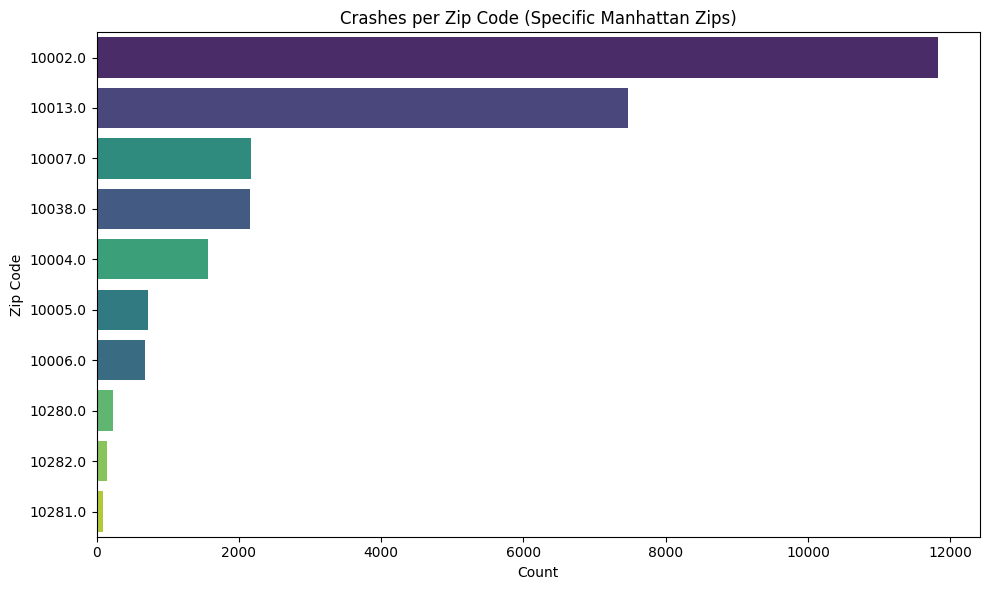

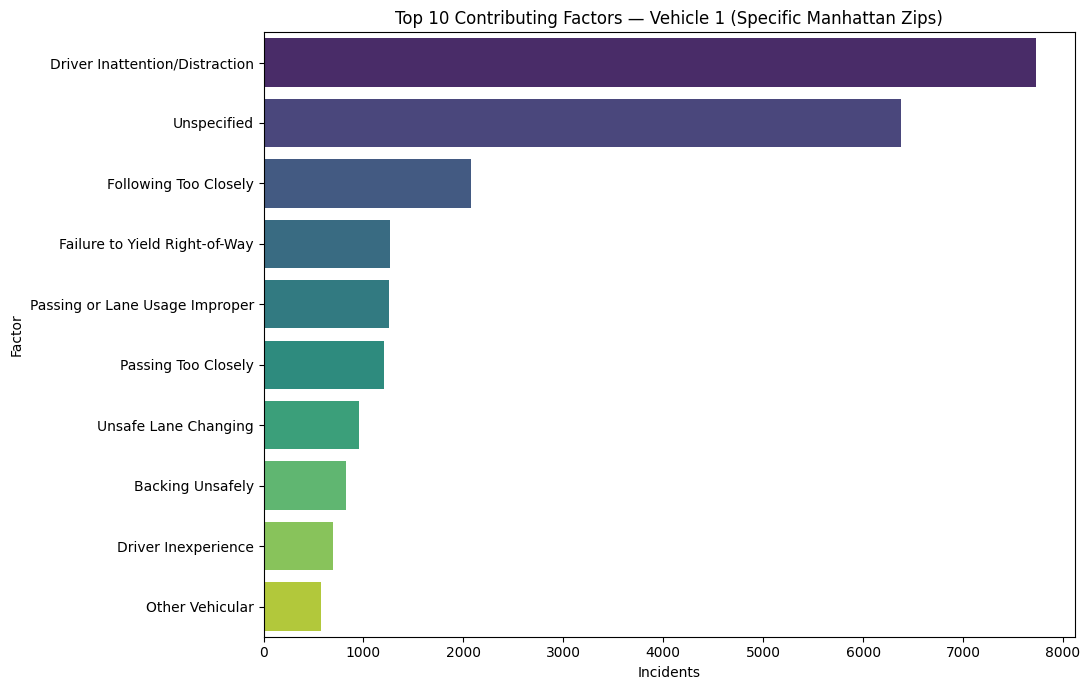

In [32]:
plt.figure(figsize=(10, 6))
order_zip = manhattan_filtered_by_zip["zip_code"].value_counts().index.astype(str)
ax_zip = sns.countplot(
    y=manhattan_filtered_by_zip["zip_code"].astype(str),
    order=order_zip,
    hue=manhattan_filtered_by_zip["zip_code"].astype(str),
    palette="viridis",
    legend=False
)
ax_zip.set_title("Crashes per Zip Code (Specific Manhattan Zips)")
ax_zip.set_xlabel("Count")
ax_zip.set_ylabel("Zip Code")
plt.tight_layout()
plt.show()

top10_filtered = manhattan_filtered_by_zip["contributing_factor_vehicle_1"].value_counts().head(10)
plt.figure(figsize=(11, 7))
ax_filtered = sns.barplot(
    x=top10_filtered.values, y=top10_filtered.index,
    hue=top10_filtered.index, palette="viridis", legend=False
)
ax_filtered.set_title("Top 10 Contributing Factors — Vehicle 1 (Specific Manhattan Zips)")
ax_filtered.set_xlabel("Incidents")
ax_filtered.set_ylabel("Factor")
plt.tight_layout()
plt.show()

### Collisions by Year in Manhattan (2018-2026) for Required Zips

In [33]:
# Convert 'crash_date' to datetime objects if not already done
manhattan_filtered_by_zip['crash_date'] = pd.to_datetime(manhattan_filtered_by_zip['crash_date'], errors='coerce')

# Define the start and end years for filtering
start_year = 2018
end_year = 2026

# Filter collisions within the specified year range
collisions_manhattan_yearly = manhattan_filtered_by_zip[
    (manhattan_filtered_by_zip['crash_date'].dt.year >= start_year) &
    (manhattan_filtered_by_zip['crash_date'].dt.year <= end_year)
].copy()

# Count collisions per year
collisions_per_year = collisions_manhattan_yearly['crash_date'].dt.year.value_counts().sort_index()

print(f"Number of collisions in Manhattan (required zips) between {start_year} and {end_year} by year:")
display(collisions_per_year)

Number of collisions in Manhattan (required zips) between 2018 and 2026 by year:


,count
crash_date,
2018,6682
2019,5836
2020,2258
2021,2382
2022,2429
2023,2362
2024,2271
2025,1952
2026,854


### EDA on Health-Related Contributing Factors

In [34]:
print("Unique values for contributing_factor_vehicle_1:")
print(combined['contributing_factor_vehicle_1'].unique())

Unique values for contributing_factor_vehicle_1:
['Aggressive Driving/Road Rage' 'Reaction to Uninvolved Vehicle'
 'Unspecified' 'Driver Inattention/Distraction' 'Backing Unsafely'
 'Unsafe Lane Changing' 'Other Vehicular' 'Passing or Lane Usage Improper'
 'Unsafe Speed' 'Following Too Closely' 'Passing Too Closely'
 'Failure to Yield Right-of-Way' 'Pavement Slippery' 'Turning Improperly'
 'Brakes Defective' 'Animals Action' 'Passenger Distraction'
 'Oversized Vehicle' 'Driver Inexperience' 'Traffic Control Disregarded'
 'Glare' 'Pedestrian/Bicyclist/Other Pedestrian Error/Confusion'
 'Fell Asleep' nan 'Illnes' 'View Obstructed/Limited'
 'Outside Car Distraction' 'Pavement Defective' 'Failure to Keep Right'
 'Fatigued/Drowsy' 'Alcohol Involvement' 'Steering Failure'
 'Tire Failure/Inadequate' 'Cell Phone (hands-free)'
 'Other Electronic Device' 'Obstruction/Debris' 'Cell Phone (hand-Held)'
 'Driverless/Runaway Vehicle' 'Lost Consciousness'
 'Traffic Control Device Improper/Non-Working'

In [35]:
# FIX #8: corrected 'ILLNES' → 'ILLNESS'
health_keywords = [
    'ILLNESS',
    'FATIGUE/DROWSY',
    'PRESCRIPTION MEDICATION',
    'PHYSICAL DISABILITY',
    'APPARENTLY ASLEEP',
    'LOST CONSCIOUSNESS',
    'SEIZURE',
    'FAINTING'
]

contributing_factor_cols = [col for col in combined.columns if col.startswith('contributing_factor_vehicle_')]

health_masks = pd.DataFrame(index=combined.index)
for col in contributing_factor_cols:
    combined[f'{col}_upper'] = combined[col].str.upper()
    health_masks[col] = combined[f'{col}_upper'].fillna('').str.contains(
        '|'.join(health_keywords), regex=True, na=False
    )

overall_health_mask    = health_masks.any(axis=1)
health_related_crashes = combined[overall_health_mask].copy()
print(f"Number of crashes with health-related contributing factors: {len(health_related_crashes):,}")
display(health_related_crashes.head())

Number of crashes with health-related contributing factors: 2,193


,collision_id,crash_date,crash_time,borough,zip_code,latitude,longitude,location,on_street_name,off_street_name,...,vehicle_type_code1,vehicle_type_code2,vehicle_type_code_3,vehicle_type_code_4,vehicle_type_code_5,contributing_factor_vehicle_1_upper,contributing_factor_vehicle_2_upper,contributing_factor_vehicle_3_upper,contributing_factor_vehicle_4_upper,contributing_factor_vehicle_5_upper
692,3821867,2018-01-03,15:40,BROOKLYN,11233.0,40.681573,-73.920120,"(40.681573, -73.920120)",ATLANTIC AVENUE,VANWYCK EXPRESSWAY,...,Sedan,Convertible,NaN,NaN,NaN,DRIVER INATTENTION/DISTRACTION,LOST CONSCIOUSNESS,NaN,NaN,NaN
1505,4061686,2018-01-04,0:00,QUEENS,11412.0,40.697815,-73.760200,"(40.697815, -73.7602)",194 STREET,114 ROAD,...,Station Wagon/Sport Utility Vehicle,Sedan,Sedan,Sedan,Sedan,LOST CONSCIOUSNESS,UNSPECIFIED,UNSPECIFIED,UNSPECIFIED,UNSPECIFIED
3375,3823648,2018-01-07,12:20,QUEENS,11106.0,40.756580,-73.929756,"(40.75658, -73.929756)",36 AVENUE,NaN,...,Station Wagon/Sport Utility Vehicle,Sedan,NaN,NaN,NaN,LOST CONSCIOUSNESS,UNSPECIFIED,NaN,NaN,NaN
4802,3825418,2018-01-09,13:30,BROOKLYN,11236.0,40.642616,-73.917340,"(40.642616, -73.91734)",PRESTON COURT,EAST 83 STREET,...,Box Truck,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN,PHYSICAL DISABILITY,UNSPECIFIED,NaN,NaN,NaN
7365,3827621,2018-01-13,12:45,QUEENS,11694.0,40.583805,-73.825560,"(40.583805, -73.82556)",BEACH 104 STREET,ROCKAWAY FREEWAY,...,Sedan,NaN,NaN,NaN,NaN,PHYSICAL DISABILITY,NaN,NaN,NaN,NaN


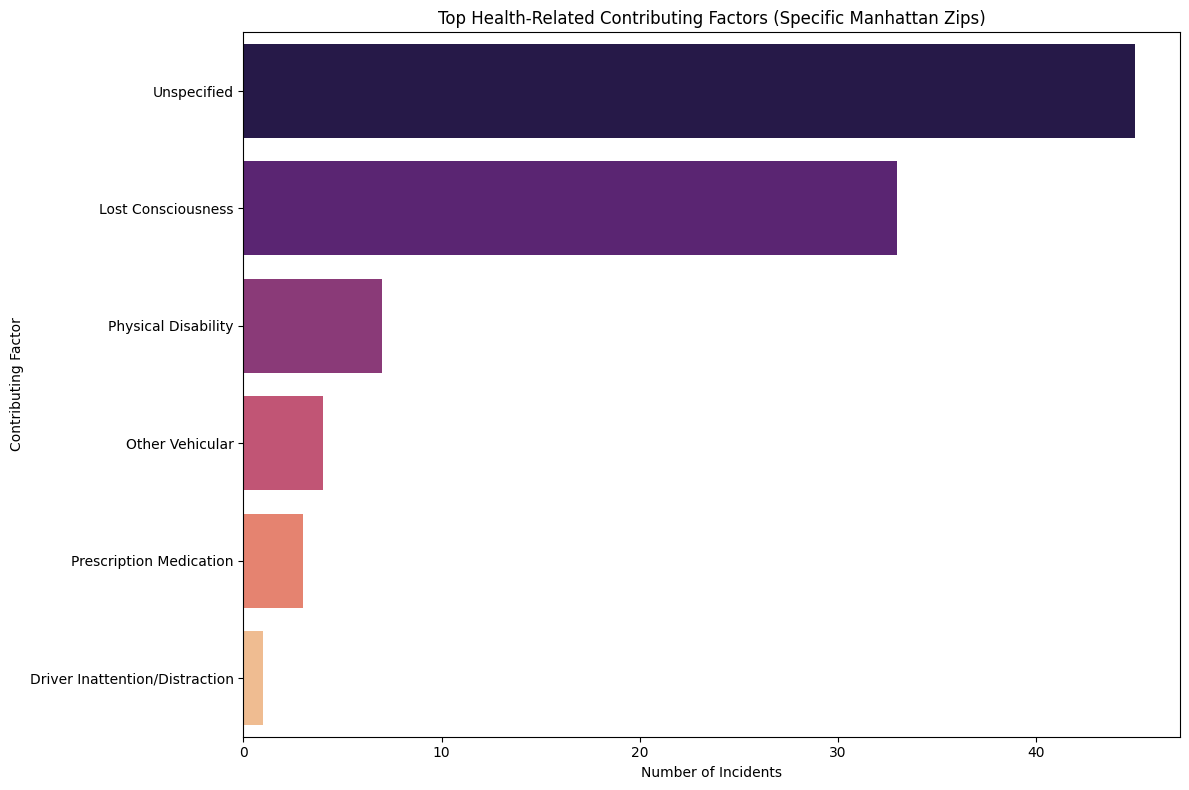

In [36]:
manhattan_health_crashes = health_related_crashes[
    health_related_crashes['collision_id'].isin(manhattan_filtered_by_zip['collision_id'])
]

if not manhattan_health_crashes.empty:
    all_health_factors = pd.concat([
        manhattan_health_crashes[col].dropna() for col in contributing_factor_cols
    ])
    top_health_factors = all_health_factors.value_counts().head(10)

    plt.figure(figsize=(12, 8))
    sns.barplot(
        x=top_health_factors.values, y=top_health_factors.index,
        hue=top_health_factors.index, palette='magma', legend=False
    )
    plt.title('Top Health-Related Contributing Factors (Specific Manhattan Zips)')
    plt.xlabel('Number of Incidents')
    plt.ylabel('Contributing Factor')
    plt.tight_layout()
    plt.show()
else:
    print("No health-related contributing factors found for the specific Manhattan zip codes.")

# Drop temporary upper-cased columns
for col in contributing_factor_cols:
    if f'{col}_upper' in combined.columns:
        combined = combined.drop(columns=[f'{col}_upper'])

### General Crash Analysis

In [37]:
worst_zips = combined['zip_code'].value_counts().head(10)
print("--- Top 10 Most Dangerous Zip Codes ---")
print(worst_zips)

borough_severity = combined.groupby('borough')[[
    'number_of_persons_injured', 'number_of_persons_killed'
]].sum()
print("\n--- Casualties by Borough ---")
print(borough_severity)

--- Top 10 Most Dangerous Zip Codes ---
zip_code
11207.0    20637
11236.0    15004
11201.0    14936
11101.0    14520
11368.0    13872
11208.0    13359
11385.0    13207
10314.0    13146
11203.0    12644
11234.0    12530
Name: count, dtype: int64

--- Casualties by Borough ---
               number_of_persons_injured  number_of_persons_killed
borough                                                           
BRONX                            81081.0                     414.0
BROOKLYN                        148639.0                     640.0
MANHATTAN                        67138.0                     345.0
QUEENS                          131640.0                     656.0
STATEN ISLAND                    21424.0                     120.0


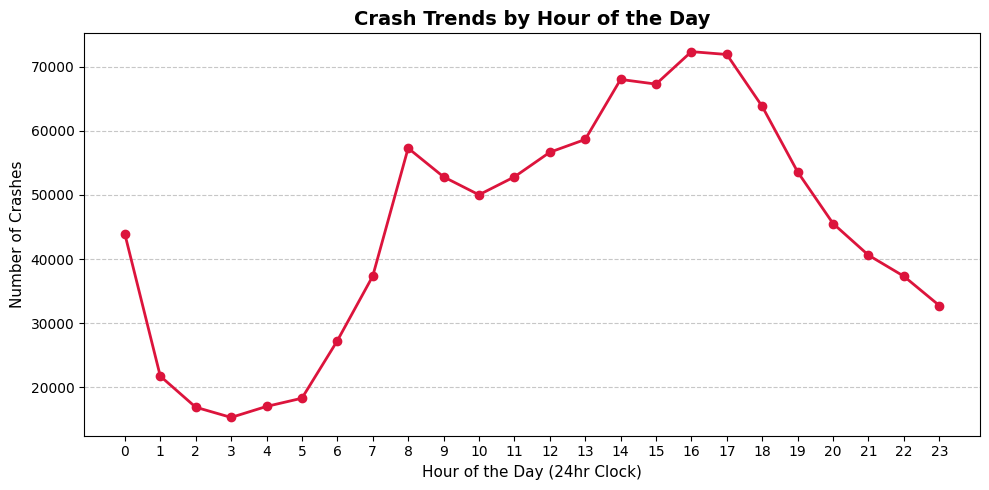

--- Peak Crash Hours ---
crash_hour
0     43898
1     21761
2     16917
3     15323
4     17035
5     18317
6     27275
7     37349
8     57297
9     52823
10    50023
11    52816
12    56653
13    58649
14    68007
15    67278
16    72341
17    71894
18    63795
19    53593
20    45548
21    40613
22    37328
23    32768
Name: count, dtype: int64


In [38]:
# FIX #7: Fully dynamic — derived from live data, covers all 24 hours
combined['crash_hour'] = pd.to_datetime(
    combined['crash_time'], format='%H:%M', errors='coerce'
).dt.hour

combined['crash_date'] = pd.to_datetime(combined['crash_date'], format='mixed')
combined['day_of_week'] = combined['crash_date'].dt.day_name()

hourly_crashes = combined['crash_hour'].value_counts().sort_index()
weekly_crashes = combined['day_of_week'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
plt.plot(hourly_crashes.index, hourly_crashes.values,
         marker='o', color='crimson', linewidth=2)
plt.title('Crash Trends by Hour of the Day', fontsize=14, fontweight='bold')
plt.xlabel('Hour of the Day (24hr Clock)', fontsize=11)
plt.ylabel('Number of Crashes', fontsize=11)
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("--- Peak Crash Hours ---")
print(hourly_crashes)

In [39]:
vehicle_danger = combined.groupby('vehicle_type_code1')[[
    'number_of_persons_injured', 'number_of_persons_killed'
]].mean()
vehicle_counts      = combined['vehicle_type_code1'].value_counts()
significant_vehicles = vehicle_counts[vehicle_counts > 100].index
print("--- Average Injuries/Deaths by Vehicle Type ---")
print(vehicle_danger.loc[significant_vehicles]
      .sort_values(by='number_of_persons_killed', ascending=False).head(10))

--- Average Injuries/Deaths by Vehicle Type ---
                    number_of_persons_injured  number_of_persons_killed
vehicle_type_code1                                                     
Motorcycle                           0.728773                  0.029760
Motorscooter                         0.833094                  0.024460
Concrete Mixer                       0.377358                  0.018868
Motorbike                            0.817797                  0.014831
Standing S                           0.955426                  0.013566
Flat Rack                            0.183562                  0.010959
Dump                                 0.274759                  0.009935
Tanker                               0.260197                  0.009845
E-Bike                               0.961407                  0.009762
Beverage Truck                       0.179724                  0.009217


In [40]:
all_streets = pd.concat([combined['on_street_name'], combined['cross_street_name']]).dropna()
top_streets = all_streets.value_counts().head(15)
print("--- Top 15 Most Dangerous Streets in NYC ---")
print(top_streets)

--- Top 15 Most Dangerous Streets in NYC ---
BELT PARKWAY                        8578
BELT PARKWAY                        6956
LONG ISLAND EXPRESSWAY              6226
BROOKLYN QUEENS EXPRESSWAY          5869
GRAND CENTRAL PKWY                  5120
BROADWAY                            4909
FDR DRIVE                           4650
LONG ISLAND EXPRESSWAY              4535
BROOKLYN QUEENS EXPRESSWAY          4464
ATLANTIC AVENUE                     4420
BROADWAY                            4074
3 AVENUE                            4066
MAJOR DEEGAN EXPRESSWAY             3834
CROSS ISLAND PARKWAY                3769
CROSS BRONX EXPY                    3662
Name: count, dtype: int64


## 9. Download and Analyze Motor Vehicle Collisions – Vehicles Data

In [41]:
VEHICLES_URL      = "https://data.cityofnewyork.us/api/views/bm4k-52h4/rows.csv?accessType=DOWNLOAD"
VEHICLES_CSV_FILE = os.path.join(DRIVE_PATH, "Motor_Vehicle_Collisions_Vehicles.csv")

print(f"Attempting to download vehicles data from: {VEHICLES_URL}")
!wget -O {VEHICLES_CSV_FILE} {VEHICLES_URL}
print(f"Successfully downloaded new vehicles data to: {VEHICLES_CSV_FILE}")

vehicles_data = pd.read_csv(VEHICLES_CSV_FILE, low_memory=False)
print(f"Loaded {len(vehicles_data):,} rows from the vehicles data file.")
display(vehicles_data.head())

Attempting to download vehicles data from: https://data.cityofnewyork.us/api/views/bm4k-52h4/rows.csv?accessType=DOWNLOAD
--2026-07-06 17:28:36--  https://data.cityofnewyork.us/api/views/bm4k-52h4/rows.csv?accessType=DOWNLOAD
Resolving data.cityofnewyork.us (data.cityofnewyork.us)... 52.206.68.26, 52.206.140.205, 52.206.140.199
Connecting to data.cityofnewyork.us (data.cityofnewyork.us)|52.206.68.26|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/csv]
Saving to: ‘/content/drive/MyDrive/BigQueryDatasets/Collisions/Motor_Vehicle_Collisions_Vehicles.csv’

/content/drive/MyDr     [           <=>      ] 803.64M  1.55MB/s    in 9m 35s  

2026-07-06 17:38:11 (1.40 MB/s) - ‘/content/drive/MyDrive/BigQueryDatasets/Collisions/Motor_Vehicle_Collisions_Vehicles.csv’ saved [842678494]

Successfully downloaded new vehicles data to: /content/drive/MyDrive/BigQueryDatasets/Collisions/Motor_Vehicle_Collisions_Vehicles.csv
Loaded 4,551,002 rows from the vehicl

,UNIQUE_ID,COLLISION_ID,CRASH_DATE,CRASH_TIME,VEHICLE_ID,STATE_REGISTRATION,VEHICLE_TYPE,VEHICLE_MAKE,VEHICLE_MODEL,VEHICLE_YEAR,...,PRE_CRASH,POINT_OF_IMPACT,VEHICLE_DAMAGE,VEHICLE_DAMAGE_1,VEHICLE_DAMAGE_2,VEHICLE_DAMAGE_3,PUBLIC_PROPERTY_DAMAGE,PUBLIC_PROPERTY_DAMAGE_TYPE,CONTRIBUTING_FACTOR_1,CONTRIBUTING_FACTOR_2
0,10385780,100201,09/07/2012,9:03,1,NY,PASSENGER VEHICLE,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Unspecified,NaN
1,19140702,4213082,09/23/2019,8:15,0553ab4d-9500-4cba-8d98-f4d7f89d5856,NY,Station Wagon/Sport Utility Vehicle,TOYT -CAR/SUV,NaN,2002.0,...,Going Straight Ahead,Left Front Bumper,Left Front Quarter Panel,NaN,NaN,NaN,N,NaN,Driver Inattention/Distraction,Unspecified
2,14887647,3307608,10/02/2015,17:18,2,NY,TAXI,NaN,NaN,NaN,...,Going Straight Ahead,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Driver Inattention/Distraction,NaN
3,14889754,3308693,10/04/2015,20:34,1,NY,PASSENGER VEHICLE,NaN,NaN,NaN,...,Parked,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Unspecified,NaN
4,14400270,297666,04/25/2013,21:15,1,NY,PASSENGER VEHICLE,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Other Vehicular,NaN


In [42]:
print(f"Shape of vehicles_data: {vehicles_data.shape}")
vehicles_data.info()

print("--- Descriptive Statistics (numeric columns) for vehicles_data ---")
display(vehicles_data.describe())

missing_vehicles     = vehicles_data.isnull().sum()
missing_pct_vehicles = missing_vehicles / len(vehicles_data) * 100
missing_df_vehicles  = pd.DataFrame({"count": missing_vehicles, "pct": missing_pct_vehicles.round(2)})
display(missing_df_vehicles[missing_df_vehicles["count"] > 0].sort_values("count", ascending=False))

Shape of vehicles_data: (4551002, 25)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4551002 entries, 0 to 4551001
Data columns (total 25 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   UNIQUE_ID                    int64  
 1   COLLISION_ID                 int64  
 2   CRASH_DATE                   object 
 3   CRASH_TIME                   object 
 4   VEHICLE_ID                   object 
 5   STATE_REGISTRATION           object 
 6   VEHICLE_TYPE                 object 
 7   VEHICLE_MAKE                 object 
 8   VEHICLE_MODEL                object 
 9   VEHICLE_YEAR                 float64
 10  TRAVEL_DIRECTION             object 
 11  VEHICLE_OCCUPANTS            float64
 12  DRIVER_SEX                   object 
 13  DRIVER_LICENSE_STATUS        object 
 14  DRIVER_LICENSE_JURISDICTION  object 
 15  PRE_CRASH                    object 
 16  POINT_OF_IMPACT              object 
 17  VEHICLE_DAMAGE               object 
 18  VEHI

,UNIQUE_ID,COLLISION_ID,VEHICLE_YEAR,VEHICLE_OCCUPANTS
count,4.551002e+06,4.551002e+06,2.569097e+06,2.720357e+06
mean,1.690909e+07,3.312324e+06,2.015598e+03,1.006752e+03
std,3.425928e+06,1.502950e+06,1.457255e+02,9.016103e+05
min,1.117110e+05,2.200000e+01,1.000000e+03,0.000000e+00
25%,1.467259e+07,3.209224e+06,2.009000e+03,1.000000e+00
50%,1.773737e+07,3.777820e+06,2.014000e+03,1.000000e+00
75%,1.973928e+07,4.342241e+06,2.017000e+03,1.000000e+00
max,2.119294e+07,4.905771e+06,2.006300e+04,1.000000e+09


,count,pct
PUBLIC_PROPERTY_DAMAGE_TYPE,4519929,99.32
VEHICLE_MODEL,4490143,98.66
VEHICLE_DAMAGE_3,3468093,76.21
VEHICLE_DAMAGE_2,3161059,69.46
VEHICLE_DAMAGE_1,2732772,60.05
DRIVER_LICENSE_STATUS,2456358,53.97
DRIVER_LICENSE_JURISDICTION,2452916,53.90
DRIVER_SEX,2349139,51.62
VEHICLE_YEAR,1981905,43.55
VEHICLE_MAKE,1955592,42.97


## 10. Download and Analyze Motor Vehicle Collisions – Person Data

In [43]:
PERSON_URL      = "https://data.cityofnewyork.us/api/views/f55k-p6yu/rows.csv?accessType=DOWNLOAD"
PERSON_CSV_FILE = os.path.join(DRIVE_PATH, "Motor_Vehicle_Collisions_Person.csv")

!wget -q -O {PERSON_CSV_FILE} {PERSON_URL}
print(f"Downloaded new person data to: {PERSON_CSV_FILE}")

person_data = pd.read_csv(PERSON_CSV_FILE, low_memory=False)
print(f"Loaded {len(person_data):,} rows from the person data file.")
display(person_data.head())

Downloaded new person data to: /content/drive/MyDrive/BigQueryDatasets/Collisions/Motor_Vehicle_Collisions_Person.csv
Loaded 5,984,132 rows from the person data file.


,UNIQUE_ID,COLLISION_ID,CRASH_DATE,CRASH_TIME,PERSON_ID,PERSON_TYPE,PERSON_INJURY,VEHICLE_ID,PERSON_AGE,EJECTION,...,BODILY_INJURY,POSITION_IN_VEHICLE,SAFETY_EQUIPMENT,PED_LOCATION,PED_ACTION,COMPLAINT,PED_ROLE,CONTRIBUTING_FACTOR_1,CONTRIBUTING_FACTOR_2,PERSON_SEX
0,10249006,4229554,10/26/2019,9:43,31aa2bc0-f545-444f-8cdb-f1cb5cf00b89,Occupant,Unspecified,19141108.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Registrant,NaN,NaN,U
1,10255054,4230587,10/25/2019,15:15,4629e500-a73e-48dc-b8fb-53124d124b80,Occupant,Unspecified,19144075.0,33.0,Not Ejected,...,Does Not Apply,"Front passenger, if two or more persons, inclu...",Lap Belt & Harness,NaN,NaN,Does Not Apply,Passenger,NaN,NaN,F
2,10253177,4230550,10/26/2019,17:55,ae48c136-1383-45db-83f4-2a5eecfb7cff,Occupant,Unspecified,19143133.0,55.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Registrant,NaN,NaN,M
3,6650180,3565527,11/21/2016,13:05,2782525,Occupant,Unspecified,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Notified Person,NaN,NaN,NaN
4,10255516,4231168,10/25/2019,11:16,e038e18f-40fb-4471-99cf-345eae36e064,Occupant,Unspecified,19144329.0,7.0,Not Ejected,...,Does Not Apply,Right rear passenger or motorcycle sidecar pas...,Lap Belt,NaN,NaN,Does Not Apply,Passenger,NaN,NaN,F


In [44]:
print(f"Shape of person_data: {person_data.shape}")
person_data.info()

print("--- Descriptive Statistics (numeric columns) for person_data ---")
display(person_data.describe())

missing_person     = person_data.isnull().sum()
missing_pct_person = missing_person / len(person_data) * 100
missing_df_person  = pd.DataFrame({"count": missing_person, "pct": missing_pct_person.round(2)})
display(missing_df_person[missing_df_person["count"] > 0].sort_values("count", ascending=False))

Shape of person_data: (5984132, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5984132 entries, 0 to 5984131
Data columns (total 21 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   UNIQUE_ID              int64  
 1   COLLISION_ID           int64  
 2   CRASH_DATE             object 
 3   CRASH_TIME             object 
 4   PERSON_ID              object 
 5   PERSON_TYPE            object 
 6   PERSON_INJURY          object 
 7   VEHICLE_ID             float64
 8   PERSON_AGE             float64
 9   EJECTION               object 
 10  EMOTIONAL_STATUS       object 
 11  BODILY_INJURY          object 
 12  POSITION_IN_VEHICLE    object 
 13  SAFETY_EQUIPMENT       object 
 14  PED_LOCATION           object 
 15  PED_ACTION             object 
 16  COMPLAINT              object 
 17  PED_ROLE               object 
 18  CONTRIBUTING_FACTOR_1  object 
 19  CONTRIBUTING_FACTOR_2  object 
 20  PERSON_SEX             object 
dtypes: float64(2), int

,UNIQUE_ID,COLLISION_ID,VEHICLE_ID,PERSON_AGE
count,5.984132e+06,5.984132e+06,5.734178e+06,5.308185e+06
mean,9.502189e+06,4.039997e+06,1.877284e+07,3.761615e+01
std,2.826829e+06,6.707613e+05,1.651204e+06,1.104724e+02
min,1.092200e+04,3.700000e+01,1.234230e+05,-9.990000e+02
25%,7.140485e+06,3.715100e+06,1.762008e+07,2.400000e+01
50%,9.657220e+06,4.080841e+06,1.884728e+07,3.600000e+01
75%,1.201820e+07,4.474453e+06,2.009505e+07,5.100000e+01
max,1.391967e+07,4.905771e+06,2.119294e+07,9.999000e+03


,count,pct
CONTRIBUTING_FACTOR_2,5877347,98.22
CONTRIBUTING_FACTOR_1,5877212,98.21
PED_LOCATION,5876812,98.21
PED_ACTION,5875925,98.19
SAFETY_EQUIPMENT,3119641,52.13
EJECTION,2905048,48.55
POSITION_IN_VEHICLE,2904693,48.54
EMOTIONAL_STATUS,2802673,46.84
BODILY_INJURY,2802630,46.83
COMPLAINT,2802623,46.83


## 11. Aggregate & Join All Three Datasets

In [45]:
print("Aggregating vehicles data...")
veh = vehicles_data.copy()
veh.columns = veh.columns.str.lower()

if 'manhattan_filtered_by_zip' in locals() and not manhattan_filtered_by_zip.empty:
    manhattan_collision_ids = manhattan_filtered_by_zip['collision_id'].unique()
    veh = veh[veh['collision_id'].isin(manhattan_collision_ids)]
    print(f"  Filtered vehicles data for {len(manhattan_collision_ids):,} Manhattan collisions.")

def join_unique(series):
    vals = series.dropna().astype(str).str.strip()
    vals = vals[vals.str.lower() != 'nan']
    unique_vals = vals.unique()
    return "|".join(unique_vals) if len(unique_vals) > 0 else None

veh_agg = veh.groupby("collision_id").agg(
    total_vehicles        = ("vehicle_id", "count"),
    vehicle_types         = ("vehicle_type", join_unique),
    vehicle_makes         = ("vehicle_make", join_unique),
    travel_directions     = ("travel_direction", join_unique),
    any_unlicensed_driver = ("driver_license_status",
                             lambda s: s.str.upper()
                             .str.contains("UNLICENSED|REVOKED|SUSPENDED", na=False).any()),
).reset_index()

cf_cols_veh = [c for c in veh.columns if c.startswith("contributing_factor")]
veh["_any_alcohol"] = veh[cf_cols_veh].apply(
    lambda row: row.str.upper().str.contains("ALCOHOL", na=False).any(), axis=1
)
v_agg_alcohol = (
    veh.groupby("collision_id")["_any_alcohol"]
    .any().reset_index()
    .rename(columns={"_any_alcohol": "any_alcohol_vehicle"})
)
veh_agg = veh_agg.merge(v_agg_alcohol, on="collision_id", how="left")
print(f"✅ Vehicles aggregated: {len(veh_agg):,} unique collisions")
print(f"   Columns: {veh_agg.columns.tolist()}")
display(veh_agg.head(3))

Aggregating vehicles data...
  Filtered vehicles data for 27,074 Manhattan collisions.
✅ Vehicles aggregated: 27,072 unique collisions
   Columns: ['collision_id', 'total_vehicles', 'vehicle_types', 'vehicle_makes', 'travel_directions', 'any_unlicensed_driver', 'any_alcohol_vehicle']


,collision_id,total_vehicles,vehicle_types,vehicle_makes,travel_directions,any_unlicensed_driver,any_alcohol_vehicle
0,3818948,2,Station Wagon/Sport Utility Vehicle,INTL -CAR/SUV|CADI -CAR/SUV,North,False,False
1,3820640,1,Station Wagon/Sport Utility Vehicle,JEEP -CAR/SUV,East,False,False
2,3820842,2,Station Wagon/Sport Utility Vehicle|Sedan,TOYT -CAR/SUV|HOND -CAR/SUV,North,False,False


In [46]:
print("\nAggregating persons data...")
per = person_data.copy()
per.columns = per.columns.str.lower()

if 'manhattan_filtered_by_zip' in locals() and not manhattan_filtered_by_zip.empty:
    manhattan_collision_ids = manhattan_filtered_by_zip['collision_id'].unique()
    per = per[per['collision_id'].isin(manhattan_collision_ids)]
    print(f"  Filtered persons data for {len(manhattan_collision_ids):,} Manhattan collisions.")

per["person_age"] = pd.to_numeric(per["person_age"], errors="coerce")
per.loc[~per["person_age"].between(0, 120), "person_age"] = np.nan

per["_is_occupant"]   = per["person_type"].str.upper().str.contains("OCCUPANT",   na=False)
per["_is_pedestrian"] = per["person_type"].str.upper().str.contains("PEDESTRIAN", na=False)
per["_is_cyclist"]    = per["person_type"].str.upper().str.contains("BICYCLIST",  na=False)
per["_killed"]        = per["person_injury"].str.upper().str.contains("KILLED",   na=False)
per["_injured"]       = per["person_injury"].str.upper().str.contains("INJURED",  na=False)

def sex_breakdown(series):
    counts = series.dropna().str.upper().value_counts()
    counts = counts[counts.index.isin(["M", "F"])]
    return "|".join(f"{k}:{v}" for k, v in counts.items()) if not counts.empty else None

cf_cols_per = [c for c in per.columns if c.startswith("contributing_factor")]
per["_any_alcohol_per"] = per[cf_cols_per].apply(
    lambda row: row.str.upper().str.contains("ALCOHOL",    na=False).any(), axis=1
)
per["_any_drug_per"] = per[cf_cols_per].apply(
    lambda row: row.str.upper().str.contains("DRUGS|DRUG", na=False).any(), axis=1
)

driver_ages = (
    per[per["_is_occupant"]]
    .groupby("collision_id")["person_age"]
    .mean().reset_index()
    .rename(columns={"person_age": "mean_driver_age"})
)

per_agg = per.groupby("collision_id").agg(
    total_persons_involved = ("person_id",       "count"),
    total_occupants        = ("_is_occupant",     "sum"),
    total_pedestrians      = ("_is_pedestrian",   "sum"),
    total_cyclists         = ("_is_cyclist",      "sum"),
    any_killed             = ("_killed",          "any"),
    any_injured            = ("_injured",         "any"),
    driver_sex_breakdown   = ("person_sex",       sex_breakdown),
    any_alcohol_person     = ("_any_alcohol_per", "any"),
    any_drug_person        = ("_any_drug_per",    "any"),
).reset_index()
per_agg = per_agg.merge(driver_ages, on="collision_id", how="left")

print(f"✅ Persons aggregated: {len(per_agg):,} unique collisions")
print(f"   Columns: {per_agg.columns.tolist()}")
display(per_agg.head(3))


Aggregating persons data...
  Filtered persons data for 27,074 Manhattan collisions.
✅ Persons aggregated: 26,993 unique collisions
   Columns: ['collision_id', 'total_persons_involved', 'total_occupants', 'total_pedestrians', 'total_cyclists', 'any_killed', 'any_injured', 'driver_sex_breakdown', 'any_alcohol_person', 'any_drug_person', 'mean_driver_age']


,collision_id,total_persons_involved,total_occupants,total_pedestrians,total_cyclists,any_killed,any_injured,driver_sex_breakdown,any_alcohol_person,any_drug_person,mean_driver_age
0,3818948,4,4,0,0,False,False,F:2|M:2,False,False,37.00
1,3820640,2,2,0,0,False,False,M:2,False,False,54.00
2,3820842,4,4,0,0,False,False,M:3|F:1,False,False,35.75


In [47]:
print("\nJoining all three datasets...")
crashes = combined.copy()

if 'manhattan_filtered_by_zip' in locals() and not manhattan_filtered_by_zip.empty:
    manhattan_filtered_collision_ids = manhattan_filtered_by_zip['collision_id'].unique()
    crashes = crashes[crashes['collision_id'].isin(manhattan_filtered_collision_ids)]
    print(f"  Filtered main crashes data for {len(manhattan_filtered_collision_ids):,} Manhattan collisions.")

upper_cols = [c for c in crashes.columns if c.endswith("_upper")]
if upper_cols:
    crashes.drop(columns=upper_cols, inplace=True)
    print(f"  Dropped {len(upper_cols)} temp '_upper' columns from crashes.")

# FIX #3: Consistent Int64 across all three before joining
crashes["collision_id"]  = pd.to_numeric(crashes["collision_id"],  errors="coerce").astype("Int64")
veh_agg["collision_id"] = pd.to_numeric(veh_agg["collision_id"], errors="coerce").astype("Int64")
per_agg["collision_id"] = pd.to_numeric(per_agg["collision_id"], errors="coerce").astype("Int64")

enriched = (
    crashes
    .merge(veh_agg, on="collision_id", how="left")
    .merge(per_agg, on="collision_id", how="left")
)

print(f"✅ Enriched table: {enriched.shape[0]:,} rows × {enriched.shape[1]} columns")
print("\n── Shape ────────────────────────────────")
print(f"  crashes  (Manhattan only): {crashes.shape}")
print(f"  veh_agg  (Manhattan only): {veh_agg.shape}")
print(f"  per_agg  (Manhattan only): {per_agg.shape}")
print(f"  enriched (Manhattan only): {enriched.shape}")
print("\n── Row count should match filtered crashes exactly ──")
assert len(enriched) == len(crashes), f"Mismatch: {len(enriched)} vs {len(crashes)}"
print("  ✅ Row counts match.")


Joining all three datasets...
  Filtered main crashes data for 27,074 Manhattan collisions.
✅ Enriched table: 27,074 rows × 47 columns

── Shape ────────────────────────────────
  crashes  (Manhattan only): (27074, 31)
  veh_agg  (Manhattan only): (27072, 7)
  per_agg  (Manhattan only): (26993, 11)
  enriched (Manhattan only): (27074, 47)

── Row count should match filtered crashes exactly ──
  ✅ Row counts match.


In [48]:
## ── CB1 Excel Export ────────────────────────────────────────────────────────
## Run this cell AFTER your pipeline has finished (combined, vehicles_data,
## and person_data must already be in memory).
## Saves a single .xlsx to Drive with three sheets — one per dataset.

!pip install openpyxl -q
import pandas as pd
from openpyxl import load_workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

# ── CB1 zip codes (Manhattan Community Board 1) ──────────────────────────────
CB1_ZIPS = [10004, 10005, 10006, 10007, 10038, 10280, 10282, 10013, 10002]

OUTPUT_PATH = "/content/drive/MyDrive/BigQueryDatasets/Collisions/CB1_Combined_Datasets.xlsx"

# ── 1. Filter crashes ─────────────────────────────────────────────────────────
crashes_cb1 = combined[combined["zip_code"].isin(CB1_ZIPS)].copy()
crashes_cb1["collision_id"] = pd.to_numeric(crashes_cb1["collision_id"], errors="coerce").astype("Int64")
print(f"Crashes (CB1):  {len(crashes_cb1):,} rows × {len(crashes_cb1.columns)} cols")

# ── 2. Filter vehicles ────────────────────────────────────────────────────────
veh = vehicles_data.copy()
veh.columns = veh.columns.str.lower()
veh["collision_id"] = pd.to_numeric(veh["collision_id"], errors="coerce").astype("Int64")
vehicles_cb1 = veh[veh["collision_id"].isin(crashes_cb1["collision_id"])].copy()
print(f"Vehicles (CB1): {len(vehicles_cb1):,} rows × {len(vehicles_cb1.columns)} cols")

# ── 3. Filter persons ─────────────────────────────────────────────────────────
per = person_data.copy()
per.columns = per.columns.str.lower()
per["collision_id"] = pd.to_numeric(per["collision_id"], errors="coerce").astype("Int64")
persons_cb1 = per[per["collision_id"].isin(crashes_cb1["collision_id"])].copy()
print(f"Persons (CB1):  {len(persons_cb1):,} rows × {len(persons_cb1.columns)} cols")

# ── 4. Write to Excel (one sheet per dataset) ─────────────────────────────────
with pd.ExcelWriter(OUTPUT_PATH, engine="openpyxl") as writer:
    crashes_cb1.to_excel(writer,  sheet_name="Crashes",  index=False)
    vehicles_cb1.to_excel(writer, sheet_name="Vehicles", index=False)
    persons_cb1.to_excel(writer,  sheet_name="Persons",  index=False)

# ── 5. Style header rows ──────────────────────────────────────────────────────
HEADER_FILL  = PatternFill("solid", start_color="1F4E79")   # dark navy
HEADER_FONT  = Font(name="Arial", bold=True, color="FFFFFF", size=10)
BODY_FONT    = Font(name="Arial", size=10)
CENTER       = Alignment(horizontal="center", vertical="center")
LEFT         = Alignment(horizontal="left",   vertical="center")
THIN         = Side(style="thin", color="BFBFBF")
BORDER       = Border(left=THIN, right=THIN, bottom=THIN)

TAB_COLORS = {"Crashes": "2E75B6", "Vehicles": "70AD47", "Persons": "ED7D31"}

wb = load_workbook(OUTPUT_PATH)

for sheet_name, df in [("Crashes", crashes_cb1), ("Vehicles", vehicles_cb1), ("Persons", persons_cb1)]:
    ws = wb[sheet_name]

    # Tab color
    ws.sheet_properties.tabColor = TAB_COLORS[sheet_name]

    # Header row
    for cell in ws[1]:
        cell.font      = HEADER_FONT
        cell.fill      = HEADER_FILL
        cell.alignment = CENTER
        cell.border    = BORDER

    # Freeze header + auto-width
    ws.freeze_panes = "A2"
    for col_idx, col_cells in enumerate(ws.iter_cols(min_row=1, max_row=ws.max_row), start=1):
        col_letter = get_column_letter(col_idx)
        max_len = max(
            (len(str(c.value)) if c.value is not None else 0) for c in col_cells
        )
        ws.column_dimensions[col_letter].width = min(max_len + 2, 40)

    # Body font + row height
    for row in ws.iter_rows(min_row=2, max_row=ws.max_row):
        ws.row_dimensions[row[0].row].height = 15
        for cell in row:
            cell.font      = BODY_FONT
            cell.alignment = LEFT
            cell.border    = BORDER

wb.save(OUTPUT_PATH)
print(f"\n✅ Saved to:\n   {OUTPUT_PATH}")
print(f"\nSheet summary:")
print(f"   Crashes  — {len(crashes_cb1):,} rows")
print(f"   Vehicles — {len(vehicles_cb1):,} rows")
print(f"   Persons  — {len(persons_cb1):,} rows")

Crashes (CB1):  26,980 rows × 31 cols
Vehicles (CB1): 52,358 rows × 25 cols
Persons (CB1):  98,754 rows × 21 cols

✅ Saved to:
   /content/drive/MyDrive/BigQueryDatasets/Collisions/CB1_Combined_Datasets.xlsx

Sheet summary:
   Crashes  — 26,980 rows
   Vehicles — 52,358 rows
   Persons  — 98,754 rows


In [49]:
## ── CB1 Excel → BigQuery Upload ─────────────────────────────────────────────
## Run AFTER the CB1 Excel export cell.
## Pushes all three sheets to BigQuery as separate tables.

!pip install google-cloud-bigquery -q
from google.colab import auth
auth.authenticate_user()

from google.cloud import bigquery
import pandas as pd

# ── Config ───────────────────────────────────────────────────────────────────
PROJECT   = "stable-liberty-426016-d2"
DATASET   = "nyc_collisions_data"
XLSX_PATH = "/content/drive/MyDrive/BigQueryDatasets/Collisions/CB1_Combined_Datasets.xlsx"

client = bigquery.Client(project=PROJECT)

SHEETS = {
    "Crashes":  "cb1_crashes",
    "Vehicles": "cb1_vehicles",
    "Persons":  "cb1_persons",
}

for sheet_name, table_name in SHEETS.items():
    print(f"Loading {sheet_name}...")
    df = pd.read_excel(XLSX_PATH, sheet_name=sheet_name)

    # Clean column names — BigQuery doesn't allow spaces or special chars
    df.columns = (
        df.columns.str.lower()
                  .str.strip()
                  .str.replace(" ", "_", regex=False)
                  .str.replace(r"[^a-z0-9_]", "", regex=True)
    )

    # Cast collision_id to Int64 for consistency
    if "collision_id" in df.columns:
        df["collision_id"] = pd.to_numeric(df["collision_id"], errors="coerce").astype("Int64")

    table_id = f"{PROJECT}.{DATASET}.{table_name}"

    job_config = bigquery.LoadJobConfig(
        write_disposition=bigquery.WriteDisposition.WRITE_TRUNCATE,  # overwrite if exists
        autodetect=True,
    )

    job = client.load_table_from_dataframe(df, table_id, job_config=job_config)
    job.result()  # wait for completion

    table = client.get_table(table_id)
    print(f"  ✅ {table_id}")
    print(f"     {table.num_rows:,} rows × {len(table.schema)} cols")
    print()

print("All three tables loaded to BigQuery ✅")

Loading Crashes...
  ✅ stable-liberty-426016-d2.nyc_collisions_data.cb1_crashes
     26,980 rows × 31 cols

Loading Vehicles...
  ✅ stable-liberty-426016-d2.nyc_collisions_data.cb1_vehicles
     52,358 rows × 25 cols

Loading Persons...
  ✅ stable-liberty-426016-d2.nyc_collisions_data.cb1_persons
     98,754 rows × 21 cols

All three tables loaded to BigQuery ✅


## 12. Save CB1 DataFrames as CSVs to Drive

In [50]:
CB1_CRASHES_CSV_FILE = os.path.join(DRIVE_PATH, "CB1_crashes.csv")
crashes_cb1.to_csv(CB1_CRASHES_CSV_FILE, index=False)
print(f"Saved crashes_cb1 to: {CB1_CRASHES_CSV_FILE}")

CB1_VEHICLES_CSV_FILE = os.path.join(DRIVE_PATH, "CB1_vehicles.csv")
vehicles_cb1.to_csv(CB1_VEHICLES_CSV_FILE, index=False)
print(f"Saved vehicles_cb1 to: {CB1_VEHICLES_CSV_FILE}")

CB1_PERSONS_CSV_FILE = os.path.join(DRIVE_PATH, "CB1_persons.csv")
persons_cb1.to_csv(CB1_PERSONS_CSV_FILE, index=False)
print(f"Saved persons_cb1 to: {CB1_PERSONS_CSV_FILE}")

Saved crashes_cb1 to: /content/drive/MyDrive/BigQueryDatasets/Collisions/CB1_crashes.csv
Saved vehicles_cb1 to: /content/drive/MyDrive/BigQueryDatasets/Collisions/CB1_vehicles.csv
Saved persons_cb1 to: /content/drive/MyDrive/BigQueryDatasets/Collisions/CB1_persons.csv


In [53]:
# Count unique collision_id from the Manhattan filtered crashes
collision_id_count = manhattan_filtered_by_zip['collision_id'].nunique()
print(f"Count of unique collision_id in Manhattan (specific zips, 2018-2026): {collision_id_count:,}")

# Count unique UNIQUE_ID from the CB1 vehicles data
vehicles_unique_id_count = vehicles_cb1['unique_id'].nunique()
print(f"Count of unique UNIQUE_ID in vehicles data (CB1 zips): {vehicles_unique_id_count:,}")

# Count unique UNIQUE_ID from the CB1 persons data
persons_unique_id_count = persons_cb1['unique_id'].nunique()
print(f"Count of unique UNIQUE_ID in persons data (CB1 zips): {persons_unique_id_count:,}")

Count of unique collision_id in Manhattan (specific zips, 2018-2026): 27,074
Count of unique UNIQUE_ID in vehicles data (CB1 zips): 52,358
Count of unique UNIQUE_ID in persons data (CB1 zips): 98,753


### Yearly Unique Counts for Collision, Vehicle, and Person Data

In [54]:
print('--- Yearly Unique Collision IDs in Manhattan (specific zips) ---')
manhattan_filtered_by_zip['crash_date'] = pd.to_datetime(manhattan_filtered_by_zip['crash_date'], errors='coerce')
yearly_collision_counts = manhattan_filtered_by_zip.groupby(manhattan_filtered_by_zip['crash_date'].dt.year)['collision_id'].nunique()
display(yearly_collision_counts)

print('\n--- Yearly Unique Vehicle IDs (CB1 zips, 2018-2026) ---')
vehicles_cb1['crash_date'] = pd.to_datetime(vehicles_cb1['crash_date'], errors='coerce')
vehicles_cb1_filtered_years = vehicles_cb1[
    (vehicles_cb1['crash_date'].dt.year >= 2018) &
    (vehicles_cb1['crash_date'].dt.year <= 2026)
]
yearly_vehicle_id_counts = vehicles_cb1_filtered_years.groupby(vehicles_cb1_filtered_years['crash_date'].dt.year)['unique_id'].nunique()
display(yearly_vehicle_id_counts)

print('\n--- Yearly Unique Person IDs (CB1 zips, 2018-2026) ---')
persons_cb1['crash_date'] = pd.to_datetime(persons_cb1['crash_date'], errors='coerce')
persons_cb1_filtered_years = persons_cb1[
    (persons_cb1['crash_date'].dt.year >= 2018) &
    (persons_cb1['crash_date'].dt.year <= 2026)
]
yearly_person_id_counts = persons_cb1_filtered_years.groupby(persons_cb1_filtered_years['crash_date'].dt.year)['unique_id'].nunique()
display(yearly_person_id_counts)

--- Yearly Unique Collision IDs in Manhattan (specific zips) ---


,collision_id
crash_date,
2018.0,6682
2019.0,5836
2020.0,2258
2021.0,2382
2022.0,2429
2023.0,2362
2024.0,2271
2025.0,1952
2026.0,854



--- Yearly Unique Vehicle IDs (CB1 zips, 2018-2026) ---


,unique_id
crash_date,
2018,13080
2019,11379
2020,4389
2021,4614
2022,4683
2023,4534
2024,4330
2025,3754
2026,1595



--- Yearly Unique Person IDs (CB1 zips, 2018-2026) ---


,unique_id
crash_date,
2018,26382
2019,22735
2020,8173
2021,8011
2022,8099
2023,8082
2024,7828
2025,6657
2026,2786


In [51]:
print("Uploading Manhattan enriched data to BigQuery...")

# Filter the enriched data for Manhattan
manhattan_enriched_data = enriched[enriched['borough'] == 'MANHATTAN'].copy()

# Define the BigQuery table ID for Manhattan enriched data
manhattan_table_name = "manhattan_enriched_crashes"
manhattan_table_id = f"{PROJECT}.{DATASET}.{manhattan_table_name}"

# Configure the load job
job_config = bigquery.LoadJobConfig(
    write_disposition=bigquery.WriteDisposition.WRITE_TRUNCATE, # Overwrite if exists
    autodetect=True,
)

# Upload the Manhattan enriched DataFrame to BigQuery
job = client.load_table_from_dataframe(manhattan_enriched_data, manhattan_table_id, job_config=job_config)
job.result() # Wait for the job to complete

table = client.get_table(manhattan_table_id)
print(f"  ✅ {manhattan_table_id}")
print(f"     {table.num_rows:,} rows × {len(table.schema)} cols")
print("Manhattan enriched data loaded to BigQuery ✅")

Uploading Manhattan enriched data to BigQuery...
  ✅ stable-liberty-426016-d2.nyc_collisions_data.manhattan_enriched_crashes
     27,074 rows × 47 cols
Manhattan enriched data loaded to BigQuery ✅
